# 06 - 24-Hour Acoustic Analysis

Continuous inference on field recordings collected over a full 24-hour period.
The trained CNN is applied to three recording sessions; results are aggregated
into temporal DataFrames and visualised across 14 figures.

### Recording sessions

| Folder | Period | Start | End |
|---|---|---|---|
| `audios_16h_00h` | Evening | Day 1 - 16:00 | Day 1 - 00:00 |
| `audios_00h_08h` | Night | Day 1 - 00:00 | Day 2 - 08:00 |
| `audios_08h_16h` | Day | Day 2 - 08:00 | Day 2 - 16:00 |

### Design decisions

- **Tram class removed:** Tram is absent from the recording site. All Tram predictions are redistributed to the model's second choice via logit masking before softmax.
- **TTA (Test-Time Augmentation):** pitch-shift ±2 semitones + time-stretch ×0.9 / ×1.1, applied to MC and Siren only.
- **Multi-resolution inference:** 1-second sub-windows for Horn and Siren; 5-second windows for all other classes. Probabilities are fused by taking the per-class maximum.
- **Adaptive confidence thresholds:** MC and Siren thresholds lowered to 0.42 to compensate for their short, variable acoustic signatures.

### Output structure

```
24h_summary.csv       <- one row per audio file
24h_events.csv        <- one row per detected event
fig1_*.png ... fig13_*.png
```

## 0. Imports and configuration

In [ ]:
import time as _time
_NOTEBOOK_START = _time.perf_counter()

In [3]:
from pathlib import Path
import numpy as _np

# ── Audio folders ────────────────────────────────────────────────────────────
FOLDERS = [
    Path("audios_16h_00h"),   # Evening : Day1 16:00 -> Day1 00:00
    Path("audios_00h_08h"),   # Night   : Day1 00:00 -> Day2 08:00
    Path("audios_08h_16h"),   # Day     : Day2 08:00 -> Day2 16:00
]
FOLDER_START_H = [16, 24, 32]
FOLDER_END_H   = [24, 32, 40]

CKPT_PATH    = Path("checkpoints/logmel_best.ckpt")
MANIFEST_CSV = Path("data/features_manifest.csv")
FEATURE_TYPE = "logmel"

# ── Audio parameters (must match notebook 03) ────────────────────────────────
SR          = 22050
DURATION    = 5.0
N_FFT       = 1024
HOP_LEN     = 512
N_MELS      = 64
FMIN        = 50
FMAX        = 8000
T_FRAMES    = int(_np.floor(SR * DURATION / HOP_LEN)) + 1
WIN_SAMPLES = int(SR * DURATION)
HOP_SAMPLES = int(SR * 1.0)

# ── Class definitions (Tram removed from active set) ─────────────────────────
CLASS2IDX_FULL = {
    'BG': 0, 'MC': 1, 'Car': 2, 'Bus': 3, 'Truck': 4,
    'Tram': 5, 'Horn': 6, 'Dog': 7, 'Construction': 8, 'Siren': 9
}
TRAM_IDX = CLASS2IDX_FULL['Tram']   # masked to -inf before softmax

CLASS2IDX = {k: v for k, v in CLASS2IDX_FULL.items() if k != 'Tram'}
IDX2CLASS  = {v: k for k, v in CLASS2IDX_FULL.items()}
CLASSES    = [k for k in CLASS2IDX_FULL if k != 'Tram']   # 9 active classes
N_CLASSES_MODEL = len(CLASS2IDX_FULL)                      # 10 (model output size)

# ── Adaptive confidence thresholds ───────────────────────────────────────────
CONF_DEFAULT = 0.50
CONF_BY_CLASS = {
    'BG':           0.50,
    'MC':           0.42,   # lowered: motorcycle often under-detected
    'Car':          0.50,
    'Bus':          0.48,
    'Truck':        0.48,
    'Horn':         0.46,
    'Dog':          0.50,
    'Construction': 0.50,
    'Siren':        0.42,   # lowered: brief and variable signal
}

# ── TTA: classes that receive augmentation ───────────────────────────────────
TTA_CLASSES = {'MC', 'Siren'}

print(f"T_FRAMES : {T_FRAMES}")
print(f"Window   : {WIN_SAMPLES/SR:.1f} s  hop {HOP_SAMPLES/SR:.1f} s")
print(f"Active classes ({len(CLASSES)}) :", CLASSES)
print(f"Suppressed class: Tram (idx {TRAM_IDX}) -> redistributed to 2nd choice")
for f, s, e in zip(FOLDERS, FOLDER_START_H, FOLDER_END_H):
    label_s = f"{s%24:02d}:00" if s < 24 else f"{s%24:02d}:00 (D2)"
    label_e = f"{e%24:02d}:00" if e <= 24 else f"{e%24:02d}:00 D2"
    n = len(list(f.glob('*.wav'))) if f.exists() else '???'
    print(f"  {str(f):<20} {label_s} -> {label_e}  ({n} files)")
print("Config OK")

T_FRAMES : 216
Window   : 5.0 s  hop 1.0 s
Active classes (9) : ['BG', 'MC', 'Car', 'Bus', 'Truck', 'Horn', 'Dog', 'Construction', 'Siren']
Suppressed class: Tram (idx 5) -> redistributed to 2nd choice
  audios_16h_00h       16:00 -> 00:00  (959 files)
  audios_00h_08h       00:00 (D2) -> 08:00 D2  (960 files)
  audios_08h_16h       08:00 (D2) -> 16:00 D2  (819 files)
Config OK


In [4]:
import numpy as np
import pandas as pd
import librosa
import librosa.display
import torch
import torch.nn as nn
import pytorch_lightning as pl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from scipy import stats
from collections import Counter
from tqdm.notebook import tqdm
from IPython.display import Audio, display, clear_output
import ipywidgets as widgets
import warnings
warnings.filterwarnings('ignore')

# ── Color palette ────────────────────────────────────────────────────────────
CLASS_COLORS = {
    'BG':           '#b0bec5',
    'MC':           '#f44336',
    'Car':          '#42a5f5',
    'Bus':          '#66bb6a',
    'Truck':        '#ff7043',
    'Horn':         '#ffca28',
    'Dog':          '#26c6da',
    'Construction': '#8d6e63',
    'Siren':        '#ec407a',
}

VEHICLE_ICONS = {
    'MC': 'MC', 'Truck': 'Truck', 'Bus': 'Bus', 'Car': 'Car',
    'Siren': 'Siren', 'Horn': 'Horn', 'Dog': 'Dog',
    'Construction': 'Construction', 'BG': 'BG',
}

PERIOD_COLORS = {'Evening': '#ff7043', 'Night': '#3949ab', 'Day': '#fdd835'}
PERIOD_ALPHA  = {'Evening': 0.15,       'Night': 0.12,      'Day': 0.10}
period_ranges = [('Evening', 16, 24), ('Night', 24, 32), ('Day', 32, 40)]

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.facecolor': '#fafafa',
    'figure.facecolor': 'white',
    'font.size': 10,
})

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")
print("Imports OK")

Device : cpu
Imports OK


---
## 1. Model and normalisation statistics

`AudioCNN` and `AudioClassifier` are reproduced here so this notebook is
self-contained. The architecture must match the checkpoint produced by notebook 05.

In [5]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, pool=(2, 2)):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True), nn.MaxPool2d(pool))
    def forward(self, x): return self.block(x)


class AudioCNN(nn.Module):
    def __init__(self, n_classes=10, dropout=0.5):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(1,   32), ConvBlock(32,  64),
            ConvBlock(64, 128), ConvBlock(128, 128),
            nn.AdaptiveAvgPool2d((4, 4)))
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Dropout(dropout),
            nn.Linear(128 * 4 * 4, 256), nn.ReLU(inplace=True),
            nn.Dropout(dropout * 0.6), nn.Linear(256, n_classes))
    def forward(self, x): return self.classifier(self.features(x))


class AudioClassifier(pl.LightningModule):
    def __init__(self, n_classes=10, class_weights=None, lr=1e-3, dropout=0.5):
        super().__init__()
        self.save_hyperparameters(ignore=['class_weights'])
        self.model     = AudioCNN(n_classes=n_classes, dropout=dropout)
        self.criterion = nn.CrossEntropyLoss(weight=class_weights)
        self.lr        = lr
    def forward(self, x): return self.model(x)
    def configure_optimizers(self): pass


model = AudioClassifier.load_from_checkpoint(
    str(CKPT_PATH), n_classes=N_CLASSES_MODEL, class_weights=None, strict=False)
model.eval().to(device)

stats_npz = np.load(MANIFEST_CSV.parent / f"norm_stats_{FEATURE_TYPE}.npz")
norm_mean  = stats_npz['mean']
norm_std   = stats_npz['std']
print("Model and normalisation stats loaded")

Model and normalisation stats loaded


---
## 2. Utility functions

### 2a. Feature extraction and audio helpers

In [6]:
def compute_logmel(y, n_frames=T_FRAMES):
    """Compute a log-mel spectrogram and pad/trim to n_frames columns."""
    S    = librosa.feature.melspectrogram(
               y=y, sr=SR, n_fft=N_FFT, hop_length=HOP_LEN,
               n_mels=N_MELS, fmin=FMIN, fmax=FMAX, power=2.0)
    S_db = librosa.power_to_db(S, ref=np.max)
    if S_db.shape[1] < n_frames:
        S_db = np.pad(S_db, ((0, 0), (0, n_frames - S_db.shape[1])),
                      mode='constant', constant_values=S_db.min())
    else:
        S_db = S_db[:, :n_frames]
    return S_db.astype(np.float32)


def center_pad(y, n=WIN_SAMPLES):
    """Center-pad or center-trim a waveform to exactly n samples."""
    if len(y) == n:
        return y
    if len(y) < n:
        p = n - len(y); l = p // 2
        return np.pad(y, (l, p - l), mode='constant')
    t = len(y) - n; l = t // 2
    return y[l:l + n]


def extract_active_region(chunk, event_dur=2.0):
    """Extract the most energetic region of a chunk (centre of mass of RMS)."""
    fl  = int(SR * 0.1)
    rms = librosa.feature.rms(y=chunk, frame_length=fl, hop_length=fl // 2)[0]
    pk  = int(np.argmax(rms)) * (fl // 2)
    es  = int(SR * event_dur)
    s   = max(0, pk - es // 2)
    e   = min(len(chunk), s + es)
    if e - s < es:
        s = max(0, e - es)
    return chunk[s:e]


def compute_rms_db(audio_path):
    """Return (dBFS, linear RMS) for an audio file."""
    y, _ = librosa.load(str(audio_path), sr=SR, mono=True)
    rms  = np.sqrt(np.mean(y ** 2))
    return float(20 * np.log10(rms + 1e-9)), float(rms)


def filename_to_abs_hour(filename, folder_start_h):
    """Parse HHMMss from filename stem and convert to absolute hour (16..40)."""
    stem  = Path(filename).stem
    parts = stem.split('_')
    if len(parts) >= 3:
        ts = parts[2]
        h, m, s = int(ts[0:2]), int(ts[2:4]), int(ts[4:6])
        local_h = h + m / 60 + s / 3600
        return local_h if folder_start_h == 16 else local_h + 24
    return folder_start_h


def abs_hour_label(abs_h):
    """Human-readable label for an absolute hour value (e.g. 25 -> '01:00 D2')."""
    h_local = abs_h % 24
    return f"{int(h_local):02d}h D2" if abs_h >= 24 else f"{int(h_local):02d}h D1"


def get_period(abs_h):
    """Return the period name for an absolute hour."""
    if 16 <= abs_h < 24:   return 'Evening'
    elif 24 <= abs_h < 32: return 'Night'
    else:                  return 'Day'


# ── Lookup helper used by interactive players ─────────────────────────────────
def get_folder(filename):
    """Return the folder Path containing filename, or None if not found."""
    for folder in FOLDERS:
        if (folder / filename).exists():
            return folder
    return None


print("Audio helpers defined")

Audio helpers defined


### 2b. Inference functions (Tram masking, TTA, multi-resolution)

In [7]:
SHORT_WIN  = int(SR * 1.0)
SHORT_T_FR = int(np.floor(SR * 1.0 / HOP_LEN)) + 1

# ── TTA transforms ────────────────────────────────────────────────────────────
TTA_TRANSFORMS = [
    lambda y: y,
    lambda y: librosa.effects.pitch_shift(y, sr=SR, n_steps=+2),
    lambda y: librosa.effects.pitch_shift(y, sr=SR, n_steps=-2),
    lambda y: librosa.effects.time_stretch(y, rate=0.9),
    lambda y: librosa.effects.time_stretch(y, rate=1.1),
]


def infer_probs(spec_norm):
    """Forward pass. Mask Tram logit to -inf before softmax."""
    x = torch.from_numpy(spec_norm).unsqueeze(0).unsqueeze(0).to(device)
    with torch.no_grad():
        logits = model(x).squeeze()
        logits[TRAM_IDX] = float('-inf')
        probs = torch.softmax(logits, dim=0).cpu().numpy()
    return probs


def infer_with_tta(segment):
    """Average probabilities over 5 TTA augmentations."""
    all_probs = []
    for transform in TTA_TRANSFORMS:
        try:
            aug = center_pad(transform(segment.copy()))
        except Exception:
            aug = center_pad(segment.copy())
        spec = compute_logmel(aug)
        spec = (spec - norm_mean) / (norm_std + 1e-6)
        all_probs.append(infer_probs(spec))
    return np.mean(all_probs, axis=0)


def predict_file(audio_path):
    """
    Run sliding-window inference on an audio file.

    Strategy:
    - 5s window, 1s hop for all classes.
    - Additional 1s sub-windows fused for Horn and Siren (multi-resolution).
    - TTA applied when MC or Siren probability exceeds 0.30.
    - Adaptive per-class confidence threshold; windows below threshold -> BG.

    Returns
    -------
    raw : list of dicts with keys t_start, t_end, pred, conf, probs
    duration : float, file duration in seconds
    """
    audio, _ = librosa.load(str(audio_path), sr=SR, mono=True)
    duration = len(audio) / SR
    starts   = list(range(0, len(audio) - WIN_SAMPLES + 1, HOP_SAMPLES))
    if not starts:
        starts = [0]

    raw = []
    for start in starts:
        window = audio[start: start + WIN_SAMPLES]
        if len(window) < WIN_SAMPLES:
            window = np.pad(window, (0, WIN_SAMPLES - len(window)))

        # 5s prediction
        segment  = center_pad(extract_active_region(window))
        spec     = (compute_logmel(segment) - norm_mean) / (norm_std + 1e-6)
        probs_5s = infer_probs(spec)

        # 1s sub-windows for Horn / Siren fusion
        sub_starts = list(range(0, len(window) - SHORT_WIN + 1, SHORT_WIN // 2))
        if not sub_starts:
            sub_starts = [0]
        short_probs_list = []
        for ss in sub_starts:
            sw = window[ss: ss + SHORT_WIN]
            if len(sw) < SHORT_WIN:
                sw = np.pad(sw, (0, SHORT_WIN - len(sw)))
            sp = compute_logmel(sw, n_frames=SHORT_T_FR)
            if SHORT_T_FR < T_FRAMES:
                sp = np.pad(sp, ((0, 0), (0, T_FRAMES - SHORT_T_FR)),
                            mode='constant', constant_values=sp.min())
            else:
                sp = sp[:, :T_FRAMES]
            sp_n = (sp - norm_mean) / (norm_std + 1e-6)
            short_probs_list.append(infer_probs(sp_n))
        probs_short = np.mean(short_probs_list, axis=0)

        # Fuse: take per-class max for Horn and Siren, then renormalise
        probs = probs_5s.copy()
        for idx_c in [CLASS2IDX_FULL['Horn'], CLASS2IDX_FULL['Siren']]:
            probs[idx_c] = max(probs_5s[idx_c], probs_short[idx_c])
        probs /= probs.sum() + 1e-9

        # TTA for MC and Siren when their probability is notable
        if (IDX2CLASS[int(np.argmax(probs))] in TTA_CLASSES
                or probs[CLASS2IDX_FULL['MC']] > 0.30
                or probs[CLASS2IDX_FULL['Siren']] > 0.30):
            probs_tta = infer_with_tta(segment)
            probs = 0.70 * probs_tta + 0.30 * probs
            probs /= probs.sum() + 1e-9

        # Adaptive threshold
        pred_idx  = int(np.argmax(probs))
        pred_cls  = IDX2CLASS[pred_idx]
        conf      = float(probs[pred_idx])
        threshold = CONF_BY_CLASS.get(pred_cls, CONF_DEFAULT)
        if conf < threshold:
            pred_cls = 'BG'
            conf     = float(probs[CLASS2IDX_FULL['BG']])

        raw.append({'t_start': start / SR,
                    't_end':   (start + WIN_SAMPLES) / SR,
                    'pred':    pred_cls, 'conf': conf, 'probs': probs})
    return raw, duration


def windows_to_events(raw):
    """Merge consecutive windows with the same prediction into events."""
    events, current = [], None
    for w in raw:
        cls, conf = w['pred'], w['conf']
        if current is None:
            current = {'cls': cls, 't_start': w['t_start'],
                       't_end': w['t_end'], 'confs': [conf]}
        elif cls == current['cls']:
            current['t_end'] = w['t_end']
            current['confs'].append(conf)
        else:
            events.append({'class':     current['cls'],
                           't_start':   round(current['t_start'], 1),
                           't_end':     round(current['t_end'],   1),
                           'duration':  round(current['t_end'] - current['t_start'], 1),
                           'conf_mean': round(float(np.mean(current['confs'])), 3),
                           'n_windows': len(current['confs'])})
            current = {'cls': cls, 't_start': w['t_start'],
                       't_end': w['t_end'], 'confs': [conf]}
    if current is not None:
        events.append({'class':     current['cls'],
                       't_start':   round(current['t_start'], 1),
                       't_end':     round(current['t_end'],   1),
                       'duration':  round(current['t_end'] - current['t_start'], 1),
                       'conf_mean': round(float(np.mean(current['confs'])), 3),
                       'n_windows': len(current['confs'])})
    return events


print("Inference functions defined")
print("Active improvements:")
print("  - Tram masked (redistributed to 2nd choice)")
print("  - TTA x5 augmentations for MC and Siren")
print("  - Multi-resolution 1s / 5s for Horn and Siren")
print("  - Adaptive thresholds:", {k: v for k, v in CONF_BY_CLASS.items() if v != CONF_DEFAULT})

Inference functions defined
Active improvements:
  - Tram masked (redistributed to 2nd choice)
  - TTA x5 augmentations for MC and Siren
  - Multi-resolution 1s / 5s for Horn and Siren
  - Adaptive thresholds: {'MC': 0.42, 'Bus': 0.48, 'Truck': 0.48, 'Horn': 0.46, 'Siren': 0.42}


---
## 3. Batch inference on all three folders (24h)

One pass over all audio files. Results are saved to CSV so this section
does not need to be re-run to regenerate figures.

In [8]:
PERIOD_LABELS   = ['Evening', 'Night', 'Day']
VEHICLE_CLASSES = ['Car', 'Truck', 'Bus', 'MC']
NOISY_CLASSES   = ['MC', 'Truck', 'Bus', 'Horn', 'Siren', 'Construction']

all_events   = []
file_summary = []

for folder, start_h, end_h, period in zip(
        FOLDERS, FOLDER_START_H, FOLDER_END_H, PERIOD_LABELS):
    audio_files = sorted(folder.glob("*.wav"))
    print(f"\n{'-'*60}")
    print(f"Folder: {folder}  ({period})  {len(audio_files)} files")
    assert len(audio_files) > 0, f"No WAV files found in {folder}"

    for audio_path in tqdm(audio_files, desc=period):
        try:
            abs_h           = filename_to_abs_hour(audio_path.name, start_h)
            db_val, rms_val = compute_rms_db(audio_path)
            raw, duration   = predict_file(audio_path)
            events          = windows_to_events(raw)
            counts          = Counter(e['class'] for e in events)

            row = {'filename':   audio_path.name, 'folder': folder.name,
                   'period':     period,           'abs_hour': abs_h,
                   'duration_s': round(duration, 1),
                   'db_rms':     round(db_val, 2),
                   'rms':        round(rms_val, 6),
                   'n_events':   len(events)}
            for c in CLASSES:
                row[f'n_{c.lower()}'] = counts.get(c, 0)
            file_summary.append(row)

            for e in events:
                all_events.append({'filename': audio_path.name,
                                   'folder': folder.name, 'period': period,
                                   'abs_hour': abs_h, **e})
        except Exception as ex:
            print(f"  [ERROR] {audio_path.name} : {ex}")
            file_summary.append({'filename': audio_path.name,
                                 'folder': folder.name, 'period': period,
                                 'error': str(ex)})

df_files  = pd.DataFrame(file_summary)
df_events = pd.DataFrame(all_events)

df_files.to_csv('24h_summary.csv',  index=False)
df_events.to_csv('24h_events.csv',  index=False)

print(f"\n{'='*60}")
print(f"  {len(df_files)} files processed")
print(f"  {len(df_events)} events detected (BG included)")
print("\nClass distribution:")
print(df_events['class'].value_counts())


------------------------------------------------------------
Folder: audios_16h_00h  (Evening)  959 files


Evening:   0%|          | 0/959 [00:00<?, ?it/s]


------------------------------------------------------------
Folder: audios_00h_08h  (Night)  960 files


Night:   0%|          | 0/960 [00:00<?, ?it/s]


------------------------------------------------------------
Folder: audios_08h_16h  (Day)  819 files


Day:   0%|          | 0/819 [00:00<?, ?it/s]


  2738 files processed
  12839 events detected (BG included)

Class distribution:
class
BG              5676
Car             4813
Truck           1294
Bus              795
MC               201
Horn              37
Siren             20
Construction       3
Name: count, dtype: int64


---
## 4. Temporal data preparation

Build `df` (file-level) and `df_hourly` (hourly aggregates).
Also defines shared axis helpers used by all figures.

In [9]:
df = df_files.dropna(subset=['abs_hour']).copy()
df = df.sort_values('abs_hour').reset_index(drop=True)
df['hour_bin']   = df['abs_hour'].apply(lambda h: int(h))
df['period']     = df['abs_hour'].apply(get_period)
df['n_vehicles'] = df[[f'n_{c.lower()}' for c in VEHICLE_CLASSES]].sum(axis=1)

hour_bins   = list(range(16, 40))
hour_labels = [abs_hour_label(h) for h in hour_bins]

df_hourly = df.groupby('hour_bin').agg(
    db_mean    = ('db_rms', 'mean'),
    db_max     = ('db_rms', 'max'),
    db_min     = ('db_rms', 'min'),
    db_std     = ('db_rms', 'std'),
    db_p90     = ('db_rms', lambda x: np.percentile(x.dropna(), 90)),
    db_p10     = ('db_rms', lambda x: np.percentile(x.dropna(), 10)),
    n_files    = ('filename', 'count'),
    n_vehicles = ('n_vehicles', 'sum'),
    n_car      = ('n_car', 'sum'),
    n_truck    = ('n_truck', 'sum'),
    n_mc       = ('n_mc', 'sum'),
    n_bus      = ('n_bus', 'sum'),
    n_horn     = ('n_horn', 'sum'),
    n_siren    = ('n_siren', 'sum'),
    n_bg       = ('n_bg', 'sum'),
).reset_index()

df_hourly = (df_hourly.set_index('hour_bin')
                       .reindex(range(16, 40))
                       .reset_index())
df_hourly['hour_label'] = df_hourly['hour_bin'].apply(abs_hour_label)
df_hourly['period']     = df_hourly['hour_bin'].apply(get_period)

xticks  = list(range(16, 41))
xlabels = []
for h in xticks:
    lh = h % 24
    if   h == 16: xlabels.append('16h\nD1')
    elif h == 24: xlabels.append('00h\nD2')
    elif h == 40: xlabels.append('16h\nD2')
    else:         xlabels.append(f'{lh:02d}h')


def add_period_bg(ax, label_ax=None, label_y_frac=0.95):
    """Shade period backgrounds and draw period-boundary verticals on ax."""
    for pname, ps, pe in period_ranges:
        ax.axvspan(ps, pe, color=PERIOD_COLORS[pname], alpha=0.07, zorder=0)
    for xv in [24, 32]:
        ax.axvline(xv, color='#aaa', linewidth=1.0, linestyle=':', zorder=4)
    if label_ax is not None:
        ylo, yhi = label_ax.get_ylim()
        for pname, ps, pe in period_ranges:
            label_ax.text((ps + pe) / 2, ylo + (yhi - ylo) * label_y_frac,
                          pname, ha='center', fontsize=9,
                          color=PERIOD_COLORS[pname], fontweight='bold', alpha=0.85)


print("Temporal data ready")
print(f"Range: abs_hour {df['abs_hour'].min():.2f} -> {df['abs_hour'].max():.2f}")
print(f"dBFS range: {df['db_rms'].min():.1f} -> {df['db_rms'].max():.1f} dB")
print(f"Total vehicle events: {int(df['n_vehicles'].sum())}")

Temporal data ready
Range: abs_hour 0.00 -> 38.82
dBFS range: -70.5 -> -29.4 dB
Total vehicle events: 7103


---
## 5. Figures

### Fig 1 - Sound levels (dBFS) over 24h with P10/P90 envelope

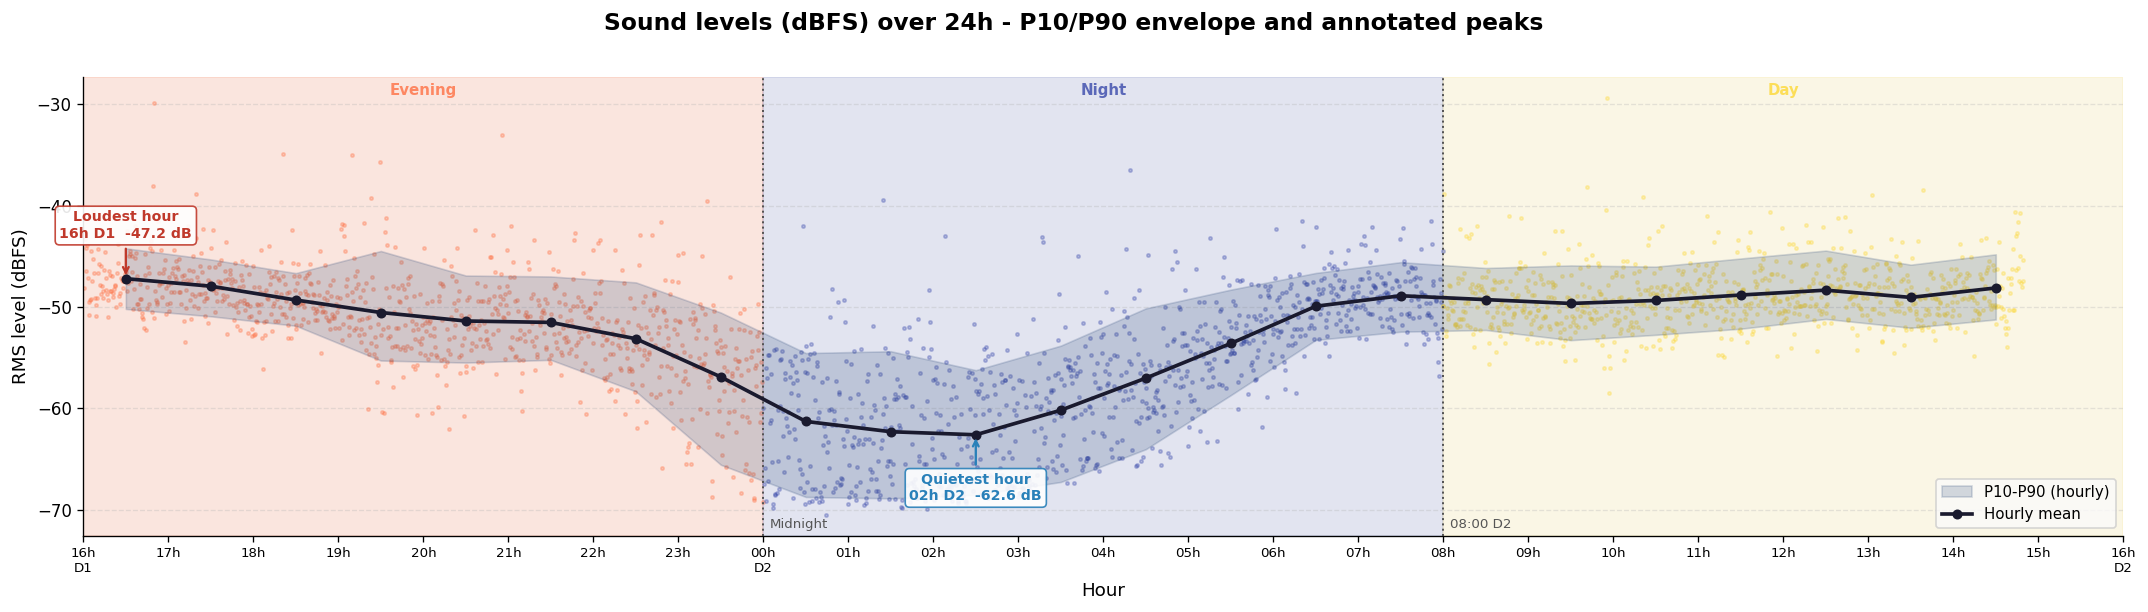

fig1_sound_levels.png


In [10]:
fig, ax = plt.subplots(figsize=(18, 5))
fig.suptitle('Sound levels (dBFS) over 24h - P10/P90 envelope and annotated peaks',
             fontsize=14, fontweight='bold', y=1.01)

for pname, ps, pe in period_ranges:
    ax.axvspan(ps, pe, color=PERIOD_COLORS[pname], alpha=PERIOD_ALPHA[pname], zorder=0)

for pname in ['Evening', 'Night', 'Day']:
    mask = df['period'] == pname
    ax.scatter(df.loc[mask, 'abs_hour'], df.loc[mask, 'db_rms'],
               c=PERIOD_COLORS[pname], s=4, alpha=0.30, zorder=2)

hb = df_hourly['hour_bin'] + 0.5
ax.fill_between(hb, df_hourly['db_p10'], df_hourly['db_p90'],
                alpha=0.18, color='#1a3a6e', zorder=3, label='P10-P90 (hourly)')
ax.plot(hb, df_hourly['db_mean'], color='#1a1a2e', linewidth=2.2,
        marker='o', markersize=5, zorder=5, label='Hourly mean')

valid = df_hourly.dropna(subset=['db_mean'])
for idx, label, color, va in [
    (valid['db_mean'].idxmax(), 'Loudest hour', '#c0392b', 'bottom'),
    (valid['db_mean'].idxmin(), 'Quietest hour', '#2980b9', 'top'),
]:
    xv = valid.loc[idx, 'hour_bin'] + 0.5
    yv = valid.loc[idx, 'db_mean']
    hl = abs_hour_label(valid.loc[idx, 'hour_bin'])
    offset = 1.5 if va == 'bottom' else -1.5
    ax.annotate(f"{label}\n{hl}  {yv:.1f} dB",
                xy=(xv, yv), xytext=(xv, yv + offset * 2.5),
                ha='center', va=va, fontsize=8.5, color=color, fontweight='bold',
                arrowprops=dict(arrowstyle='->', color=color, lw=1.4),
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                          edgecolor=color, alpha=0.9), zorder=8)

ax.set_xticks(xticks); ax.set_xticklabels(xlabels, fontsize=8)
ax.set_xlim(16, 40); ax.set_ylabel('RMS level (dBFS)', fontsize=11)
ax.set_xlabel('Hour', fontsize=11); ax.legend(loc='lower right', fontsize=9)
ax.grid(axis='y', alpha=0.3, linestyle='--')

ylo, yhi = ax.get_ylim()
for pname, ps, pe in period_ranges:
    ax.text((ps + pe) / 2, yhi - (yhi - ylo) * 0.04, pname,
            ha='center', fontsize=9, color=PERIOD_COLORS[pname],
            fontweight='bold', alpha=0.8)
for xv, lbl in [(24, 'Midnight'), (32, '08:00 D2')]:
    ax.axvline(xv, color='#555', linewidth=1.2, linestyle=':', zorder=4)
    ax.text(xv + 0.08, ylo + 0.5, lbl, fontsize=8, color='#555', va='bottom')

plt.tight_layout()
plt.savefig('fig1_sound_levels.png', dpi=150, bbox_inches='tight')
plt.show()
print("fig1_sound_levels.png")

### Fig 2 - Vehicle events per hour with dBFS secondary axis

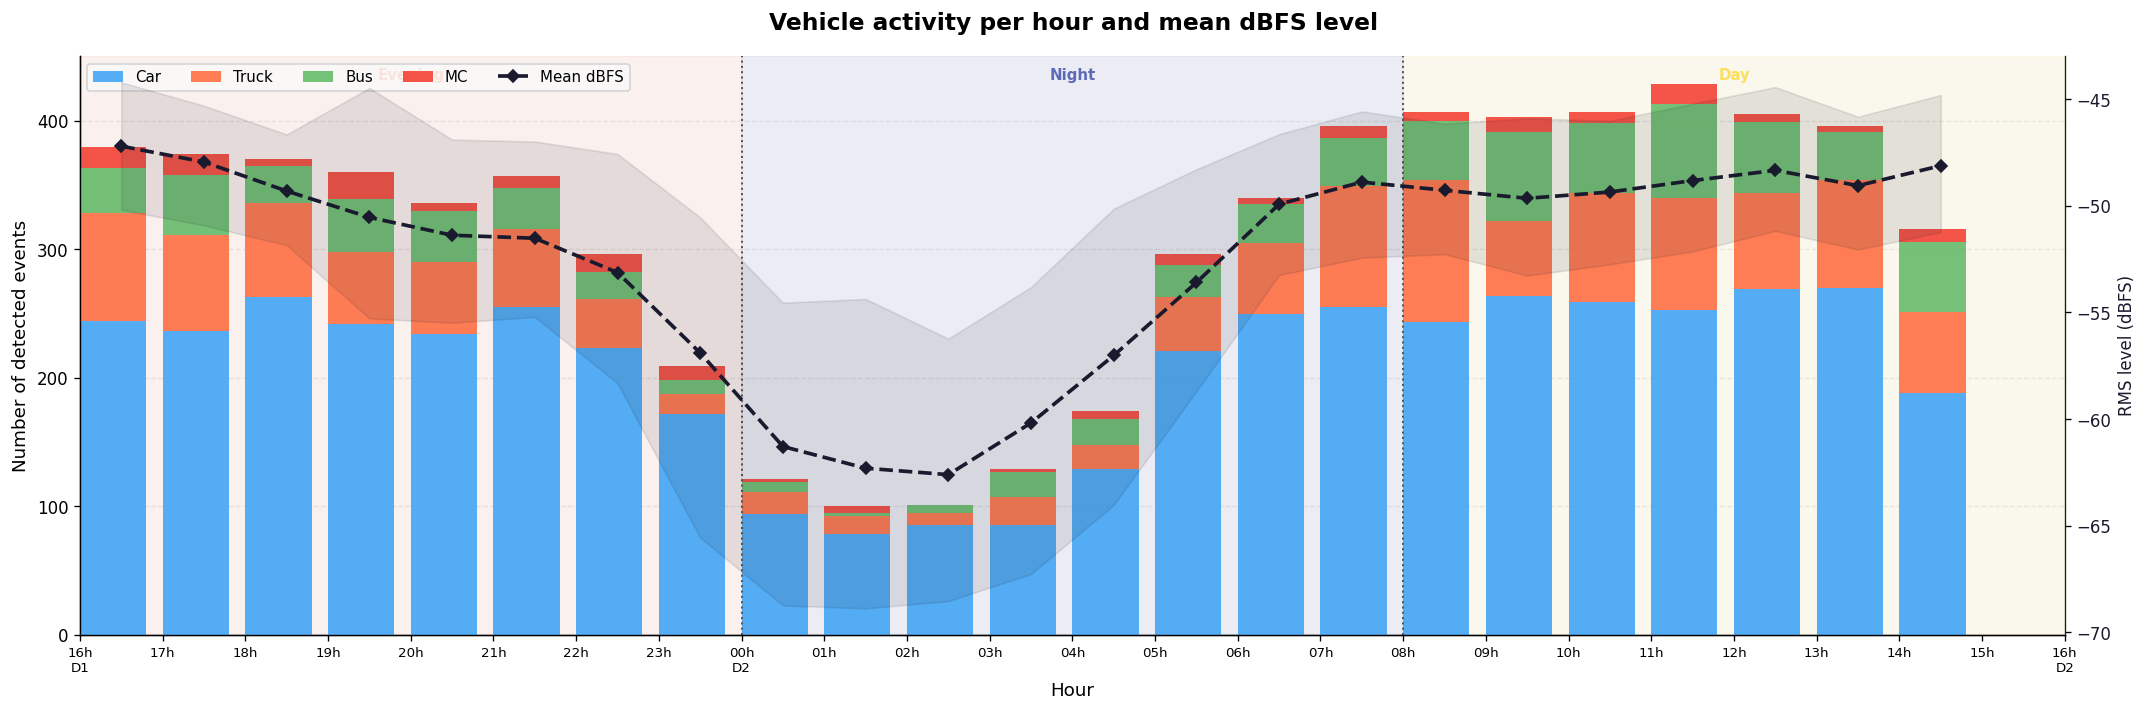

fig2_vehicles_dbfs.png


In [11]:
fig, ax = plt.subplots(figsize=(18, 6))
ax2 = ax.twinx()
fig.suptitle('Vehicle activity per hour and mean dBFS level',
             fontsize=14, fontweight='bold')

vehicle_plot_classes = ['Car', 'Truck', 'Bus', 'MC']
hb     = df_hourly['hour_bin'].values
bottom = np.zeros(len(df_hourly))
for cls in vehicle_plot_classes:
    vals = df_hourly[f'n_{cls.lower()}'].fillna(0).values
    ax.bar(hb + 0.4, vals, bottom=bottom, width=0.8,
           color=CLASS_COLORS[cls], label=cls, zorder=3, alpha=0.9)
    bottom += vals

hb_c = df_hourly['hour_bin'] + 0.5
ax2.plot(hb_c, df_hourly['db_mean'], color='#1a1a2e', linewidth=2.2,
         marker='D', markersize=5, zorder=6, label='Mean dBFS', linestyle='--')
ax2.fill_between(hb_c, df_hourly['db_p10'], df_hourly['db_p90'],
                 alpha=0.10, color='#1a1a2e', zorder=5)
ax2.set_ylabel('RMS level (dBFS)', fontsize=10, color='#1a1a2e')
ax2.tick_params(axis='y', labelcolor='#1a1a2e')
ax2.spines['right'].set_visible(True); ax2.spines['right'].set_color('#1a1a2e')
ax2.spines['top'].set_visible(False)

for pname, ps, pe in period_ranges:
    ax.axvspan(ps, pe, color=PERIOD_COLORS[pname], alpha=0.07, zorder=0)
for xv in [24, 32]:
    ax.axvline(xv, color='#555', linewidth=1.2, linestyle=':', zorder=4)

ax.set_xticks(xticks); ax.set_xticklabels(xlabels, fontsize=8)
ax.set_xlim(16, 40); ax.set_ylabel('Number of detected events', fontsize=11)
ax.set_xlabel('Hour', fontsize=11); ax.grid(axis='y', alpha=0.25, linestyle='--')

h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc='upper left', fontsize=9,
          ncol=len(vehicle_plot_classes) + 1)

ylo, yhi = ax.get_ylim()
for pname, ps, pe in period_ranges:
    ax.text((ps + pe) / 2, yhi * 0.96, pname, ha='center', fontsize=9,
            color=PERIOD_COLORS[pname], fontweight='bold', alpha=0.8)

plt.tight_layout()
plt.savefig('fig2_vehicles_dbfs.png', dpi=150, bbox_inches='tight')
plt.show()
print("fig2_vehicles_dbfs.png")

### Fig 3 - Evening / Night / Day sound level comparison

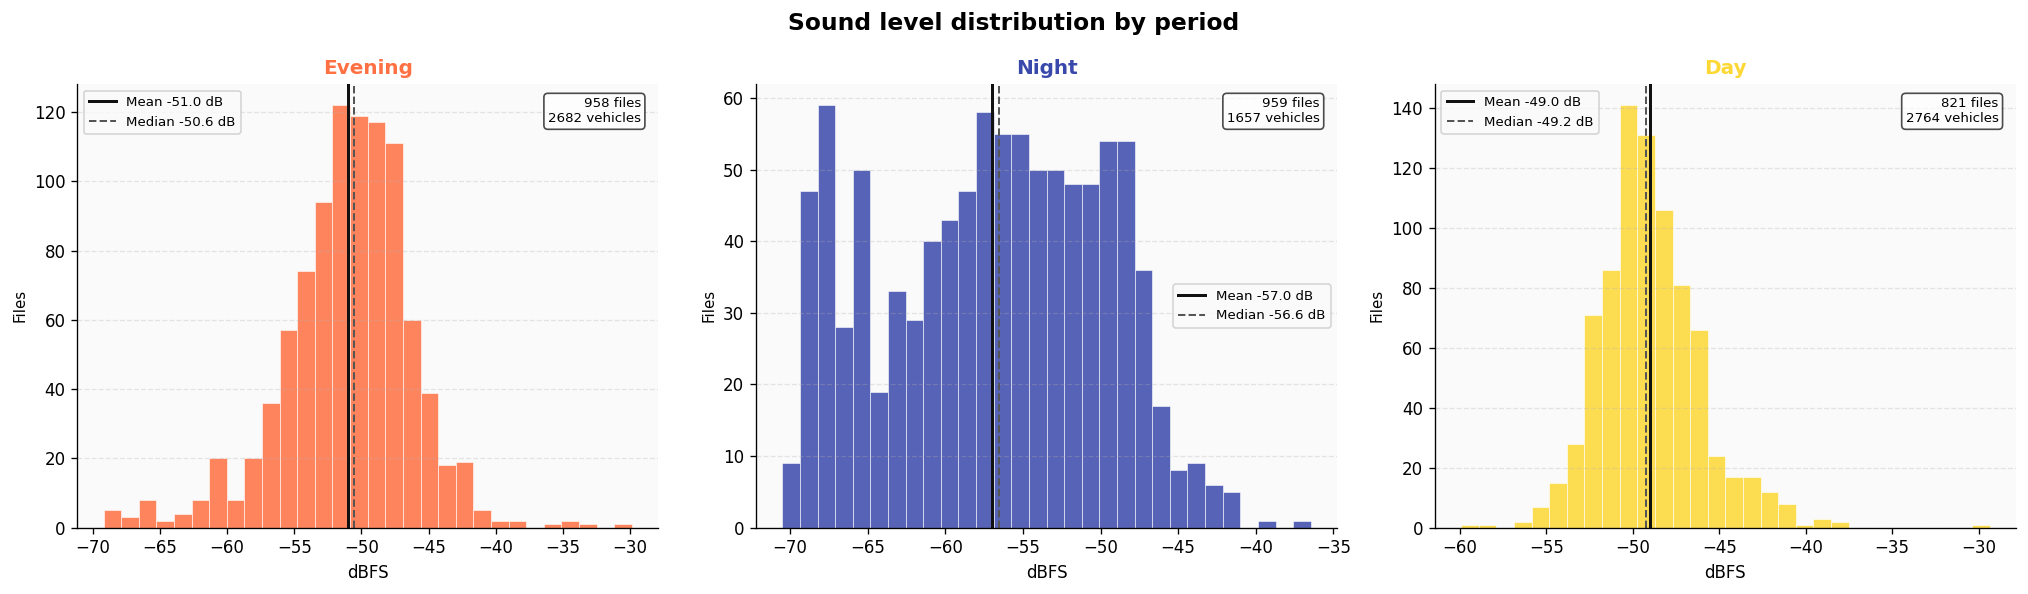

fig3_period_comparison.png


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Sound level distribution by period', fontsize=14, fontweight='bold')

for ax, period in zip(axes, ['Evening', 'Night', 'Day']):
    sub = df[df['period'] == period]
    ax.hist(sub['db_rms'].dropna(), bins=30,
            color=PERIOD_COLORS[period], alpha=0.85, edgecolor='white', linewidth=0.4)
    mu  = sub['db_rms'].mean(); med = sub['db_rms'].median()
    ax.axvline(mu,  color='#111', linewidth=1.8, linestyle='-',
               label=f'Mean {mu:.1f} dB')
    ax.axvline(med, color='#555', linewidth=1.2, linestyle='--',
               label=f'Median {med:.1f} dB')
    ax.set_title(period, fontsize=12, fontweight='bold', color=PERIOD_COLORS[period])
    ax.set_xlabel('dBFS', fontsize=10); ax.set_ylabel('Files', fontsize=9)
    ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3, linestyle='--')
    n_veh = sub['n_vehicles'].sum()
    ax.text(0.97, 0.97, f"{len(sub)} files\n{int(n_veh)} vehicles",
            transform=ax.transAxes, ha='right', va='top', fontsize=8,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

plt.tight_layout()
plt.savefig('fig3_period_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("fig3_period_comparison.png")

### Fig 4 - Raw and normalised class heatmaps

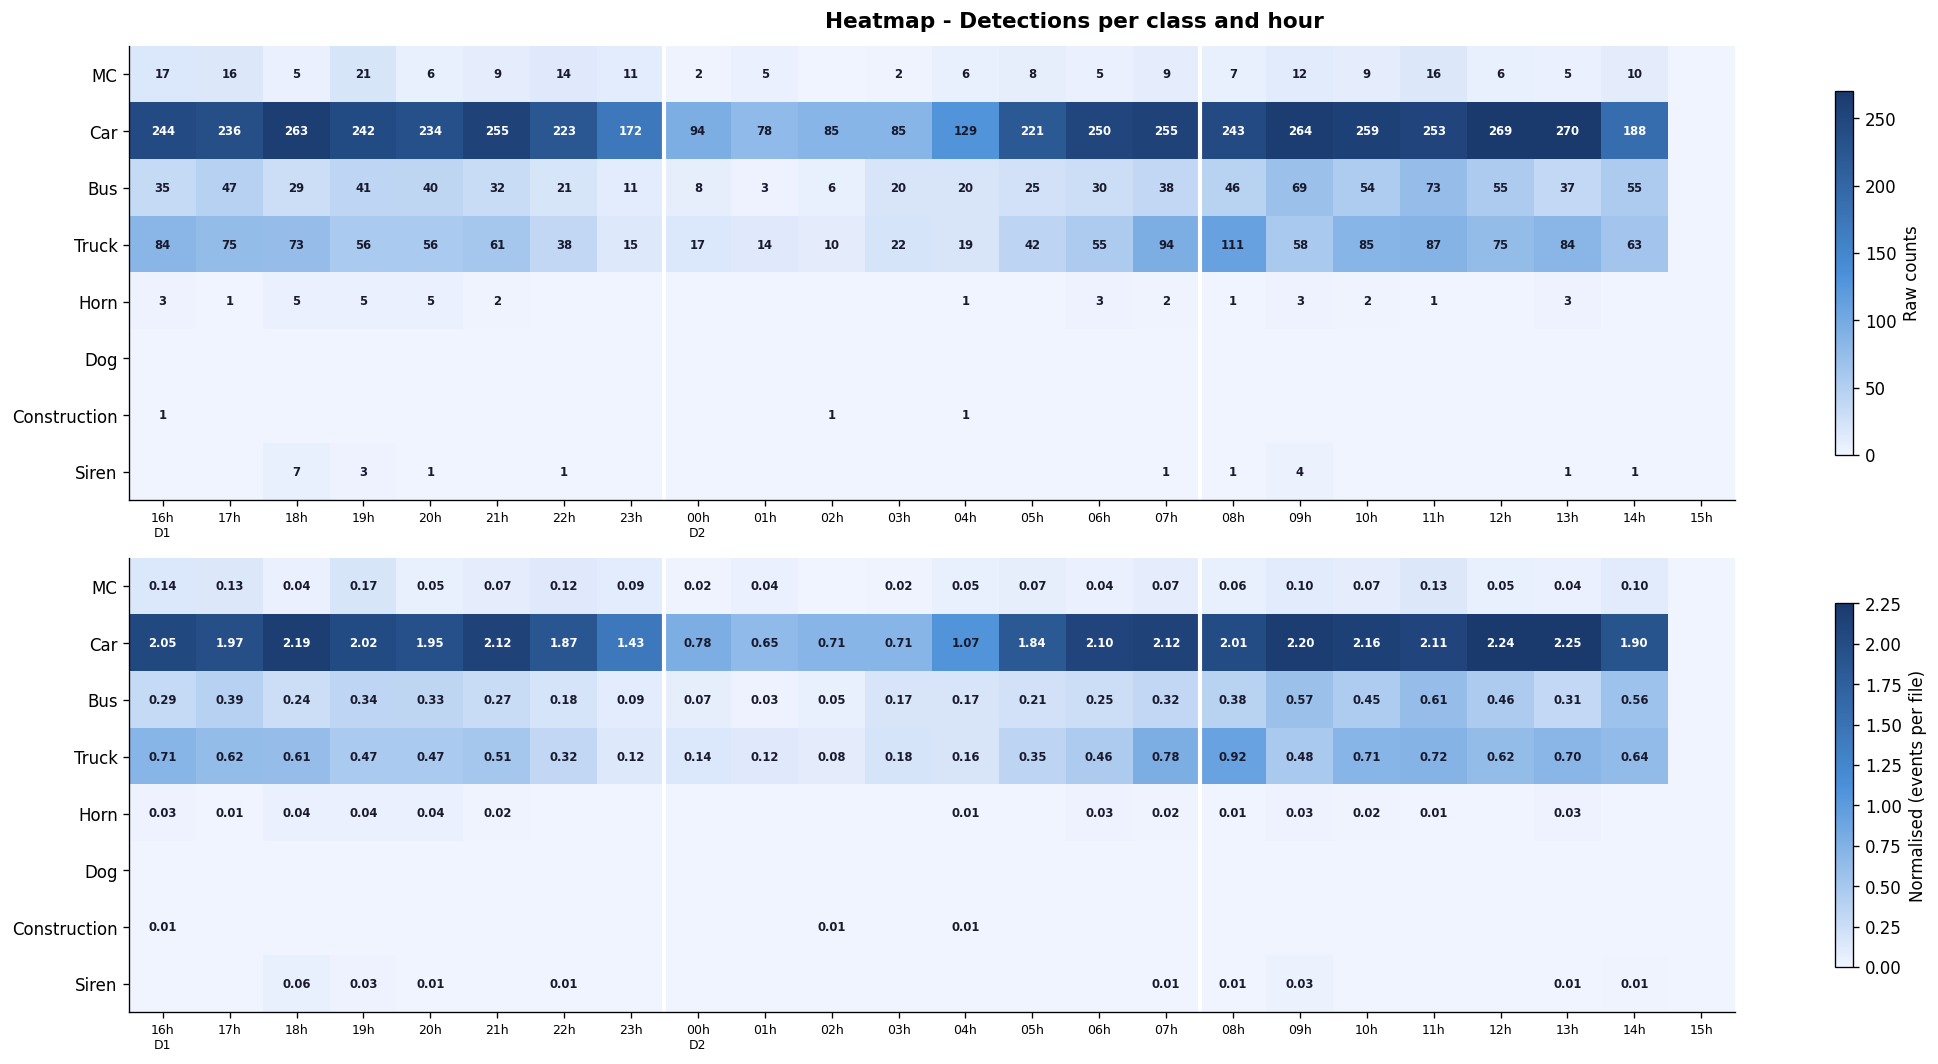

fig4_heatmap.png


In [13]:
plot_classes = [c for c in CLASSES if c != 'BG']
heat_raw  = np.zeros((len(plot_classes), 24))
n_files_h = np.ones(24)

for j, h in enumerate(range(16, 40)):
    row = df_hourly[df_hourly['hour_bin'] == h]
    nf  = row['n_files'].fillna(0).values[0] if len(row) > 0 else 0
    n_files_h[j] = max(nf, 1)
    for i, cls in enumerate(plot_classes):
        col = f'n_{cls.lower()}'
        if len(row) > 0 and col in row.columns:
            heat_raw[i, j] = row[col].fillna(0).values[0]
        else:
            mask = df['hour_bin'] == h
            heat_raw[i, j] = df.loc[mask, col].sum() if col in df.columns else 0

heat_norm = heat_raw / n_files_h[np.newaxis, :]
cmap_h = LinearSegmentedColormap.from_list(
    'custom', ['#f0f4ff', '#4a90d9', '#1a3a6e'], N=256)

fig, axes = plt.subplots(2, 1, figsize=(18, 9))
fig.suptitle('Heatmap - Detections per class and hour',
             fontsize=13, fontweight='bold')

for ax, data, title, fmt in [
    (axes[0], heat_raw,  'Raw counts',                        '{:.0f}'),
    (axes[1], heat_norm, 'Normalised (events per file)',       '{:.2f}'),
]:
    im = ax.imshow(data, aspect='auto', cmap=cmap_h,
                   origin='upper', interpolation='nearest')
    plt.colorbar(im, ax=ax, label=title, shrink=0.8)
    ax.set_yticks(range(len(plot_classes)))
    ax.set_yticklabels(plot_classes, fontsize=10)
    ax.set_xticks(range(24)); ax.set_xticklabels(xlabels[:24], fontsize=7.5)
    for sep in [8, 16]:
        ax.axvline(sep - 0.5, color='white', linewidth=2.5)
    vmax = data.max()
    for i in range(len(plot_classes)):
        for j in range(24):
            v = data[i, j]
            if v > 0:
                ax.text(j, i, fmt.format(v), ha='center', va='center',
                        fontsize=7,
                        color='white' if v > vmax * 0.5 else '#1a1a2e',
                        fontweight='bold')

plt.tight_layout()
plt.savefig('fig4_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("fig4_heatmap.png")

### Fig 5 - Global class distribution (pie + bar)

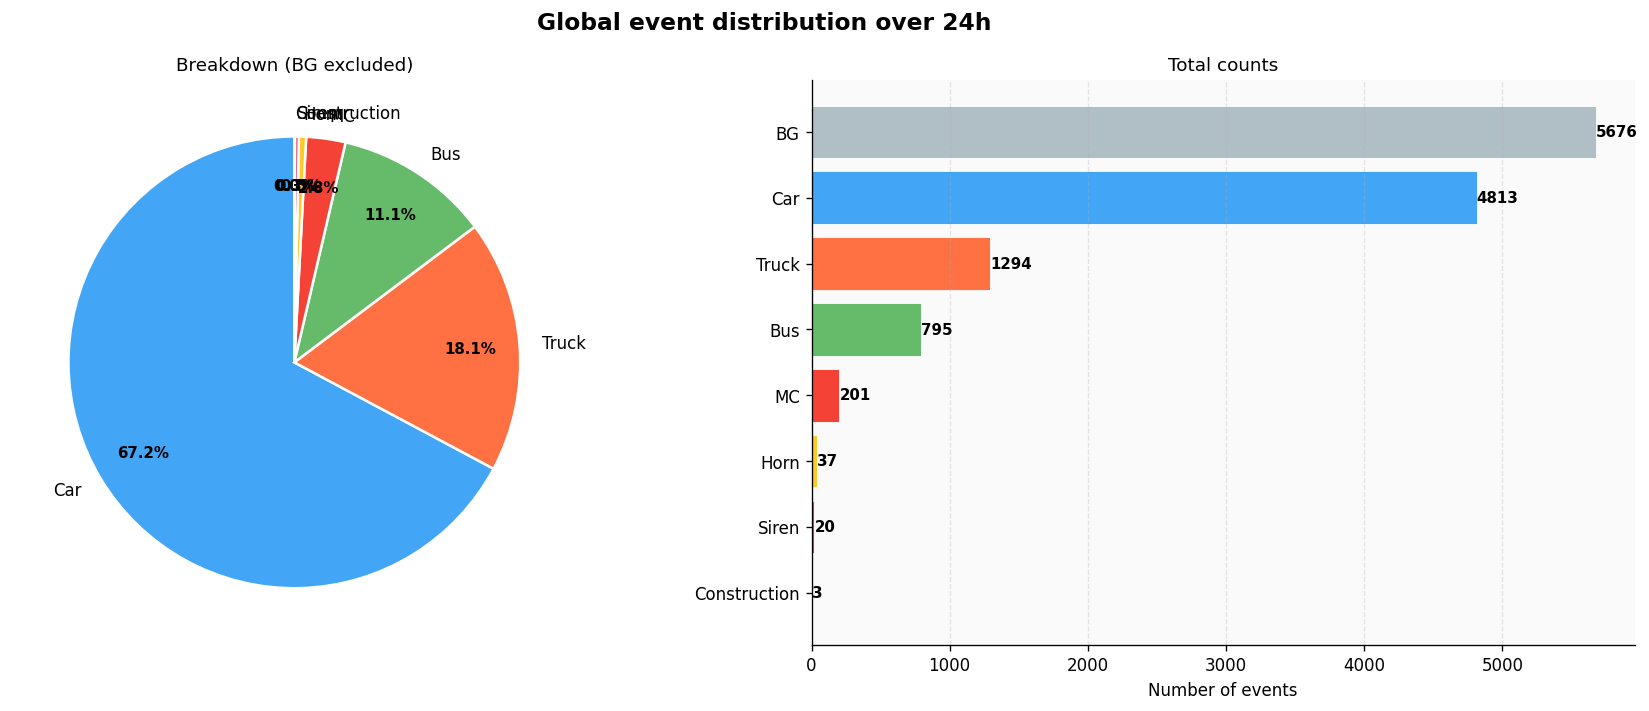

fig5_class_distribution.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Global event distribution over 24h',
             fontsize=14, fontweight='bold')

class_counts = df_events['class'].value_counts()
non_bg       = class_counts.drop(['BG', 'Tram'], errors='ignore')

ax = axes[0]
sizes  = non_bg.values; labels = non_bg.index
colors = [CLASS_COLORS.get(c, '#999') for c in labels]
wedges, texts, autotexts = ax.pie(
    sizes, labels=labels, colors=colors, autopct='%1.1f%%',
    startangle=90, pctdistance=0.78,
    wedgeprops=dict(linewidth=1.5, edgecolor='white'))
for t in autotexts:
    t.set_fontsize(9); t.set_fontweight('bold')
ax.set_title('Breakdown', fontsize=11)

ax2 = axes[1]
bar_colors = [CLASS_COLORS.get(c, '#999') for c in class_counts.index]
bars = ax2.barh(class_counts.index[::-1], class_counts.values[::-1],
                color=bar_colors[::-1], edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, class_counts.values[::-1]):
    ax2.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
             f'{val}', va='center', fontsize=9, fontweight='bold')
ax2.set_xlabel('Number of events', fontsize=10)
ax2.set_title('Total counts', fontsize=11)
ax2.grid(axis='x', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('fig5_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("fig5_class_distribution.png")

### Fig 6 - Multi-metric temporal evolution (dBFS + vehicle sub-panels)

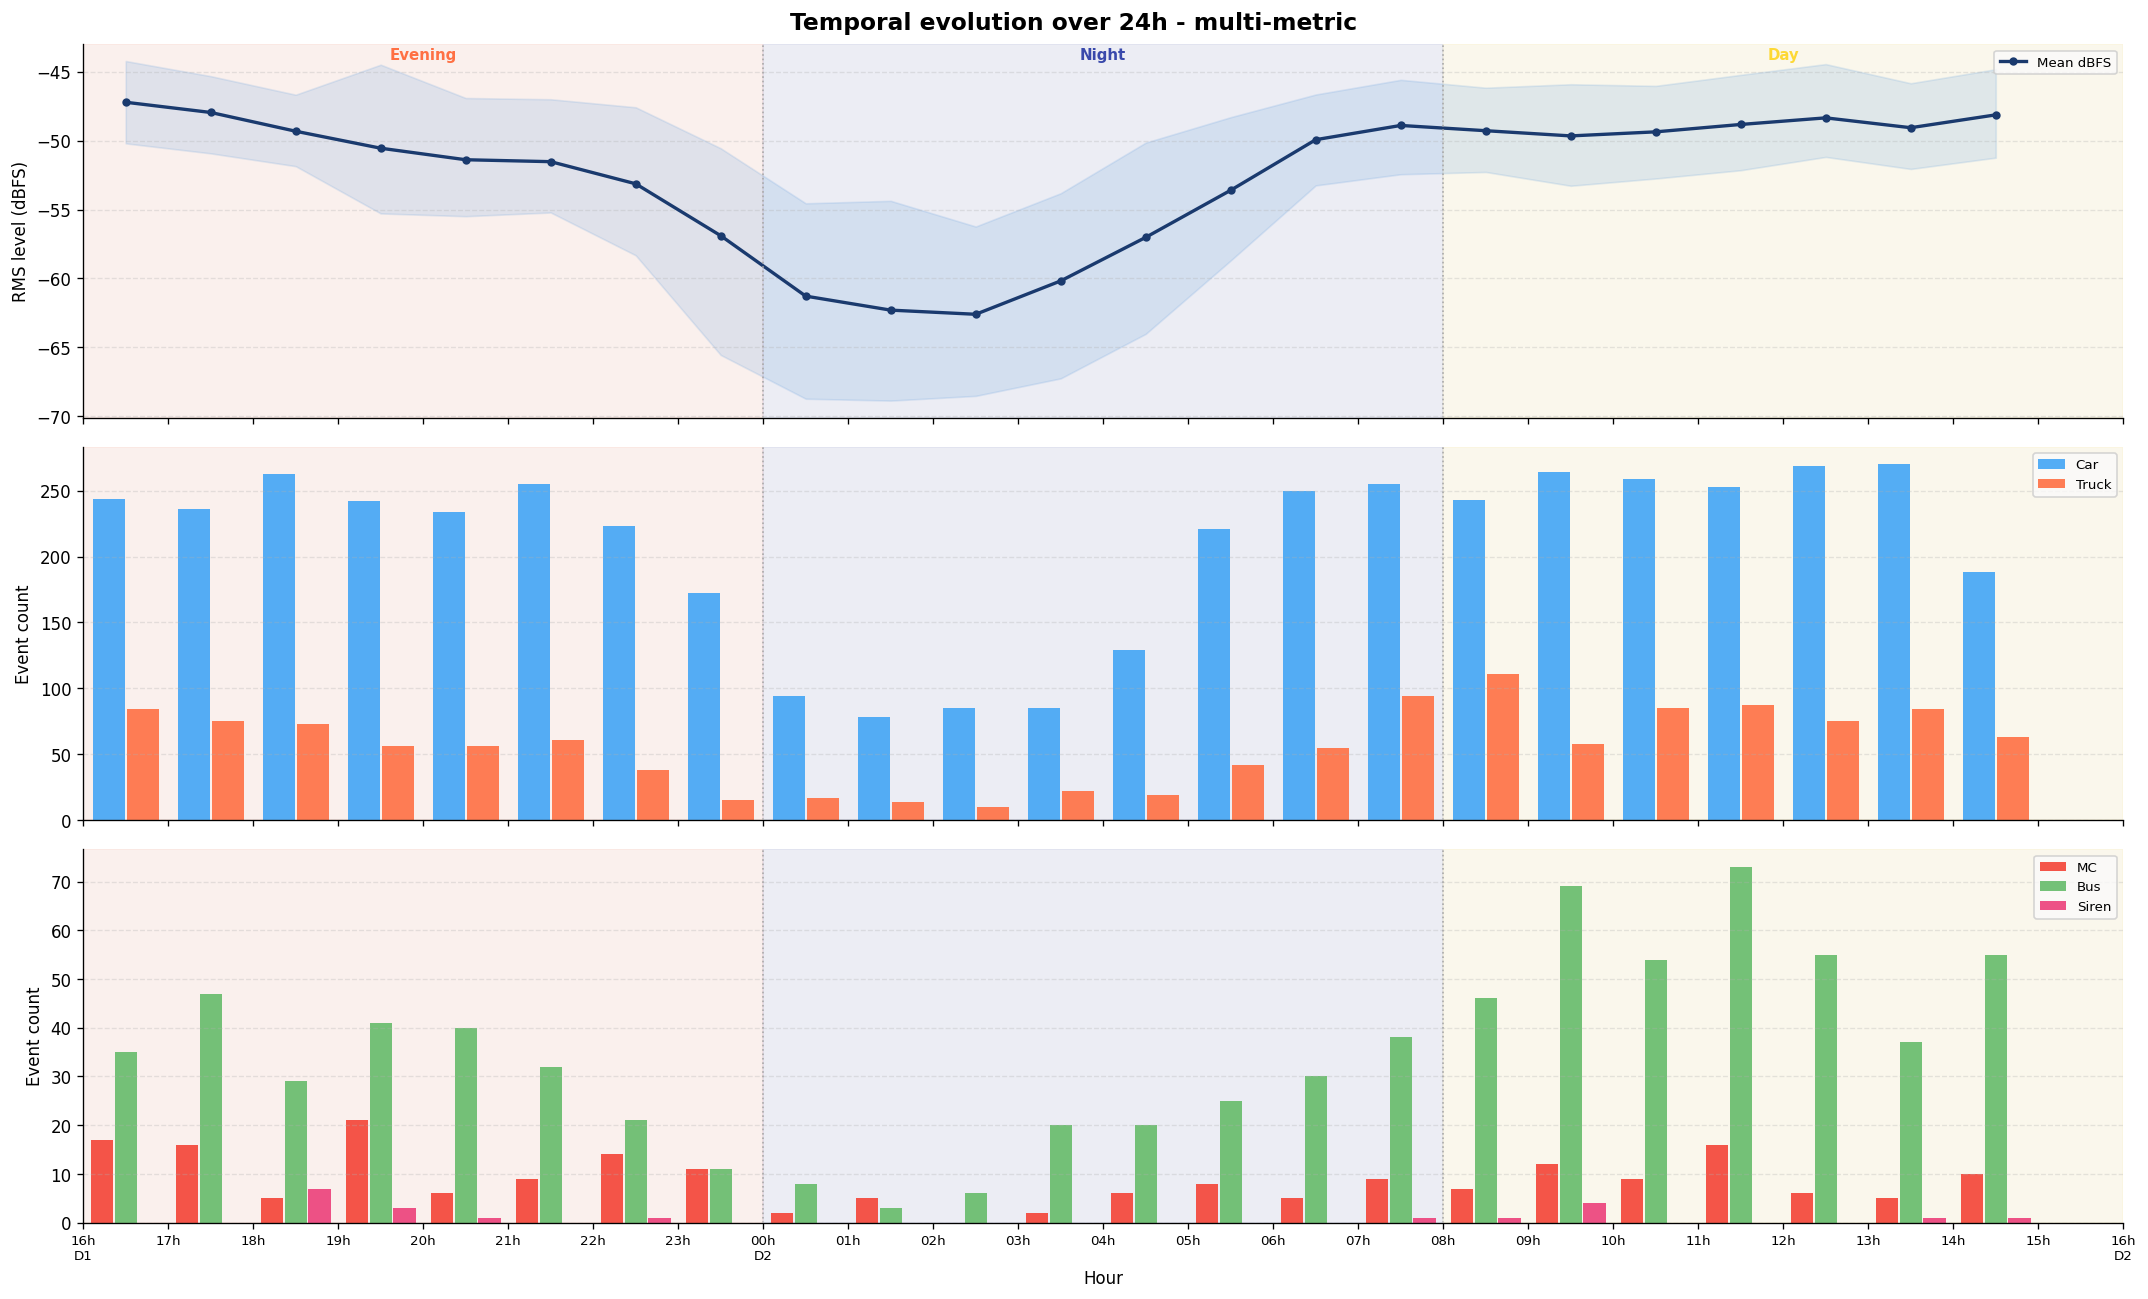

fig6_multi_metric.png


In [15]:
fig, axes = plt.subplots(3, 1, figsize=(18, 11), sharex=True)
fig.suptitle('Temporal evolution over 24h - multi-metric',
             fontsize=14, fontweight='bold')
hb_c = df_hourly['hour_bin'] + 0.5

ax = axes[0]; add_period_bg(ax)
ax.fill_between(hb_c, df_hourly['db_p10'], df_hourly['db_p90'],
                alpha=0.15, color='#4a90d9')
ax.plot(hb_c, df_hourly['db_mean'], color='#1a3a6e', linewidth=2.0,
        marker='o', markersize=4, label='Mean dBFS')
ax.set_ylabel('RMS level (dBFS)', fontsize=10)
ax.legend(fontsize=8, loc='upper right')
ax.grid(axis='y', alpha=0.3, linestyle='--')

ax = axes[1]; add_period_bg(ax)
ax.bar(hb_c - 0.2, df_hourly['n_car'].fillna(0),   width=0.38,
       color=CLASS_COLORS['Car'],   alpha=0.9, label='Car')
ax.bar(hb_c + 0.2, df_hourly['n_truck'].fillna(0), width=0.38,
       color=CLASS_COLORS['Truck'], alpha=0.9, label='Truck')
ax.set_ylabel('Event count', fontsize=10)
ax.legend(fontsize=8, loc='upper right')
ax.grid(axis='y', alpha=0.3, linestyle='--')

ax = axes[2]; add_period_bg(ax)
ax.bar(hb_c - 0.28, df_hourly['n_mc'].fillna(0),    width=0.26,
       color=CLASS_COLORS['MC'],    alpha=0.9, label='MC')
ax.bar(hb_c,        df_hourly['n_bus'].fillna(0),   width=0.26,
       color=CLASS_COLORS['Bus'],   alpha=0.9, label='Bus')
ax.bar(hb_c + 0.28, df_hourly['n_siren'].fillna(0), width=0.26,
       color=CLASS_COLORS['Siren'], alpha=0.9, label='Siren')
ax.set_ylabel('Event count', fontsize=10)
ax.set_xlabel('Hour', fontsize=10)
ax.legend(fontsize=8, loc='upper right')
ax.grid(axis='y', alpha=0.3, linestyle='--')

axes[2].set_xticks(xticks); axes[2].set_xticklabels(xlabels, fontsize=8)
axes[2].set_xlim(16, 40)

ylo, yhi = axes[0].get_ylim()
for pname, ps, pe in period_ranges:
    axes[0].text((ps + pe) / 2, yhi - (yhi - ylo) * 0.04, pname,
                 ha='center', fontsize=9, color=PERIOD_COLORS[pname],
                 fontweight='bold')

plt.tight_layout()
plt.savefig('fig6_multi_metric.png', dpi=150, bbox_inches='tight')
plt.show()
print("fig6_multi_metric.png")

---
## 6. Peak detection and loudest moments

One full scan over all audio files to find the top-20 loudest 1-second windows,
de-duplicated with a 30-second minimum gap.

In [30]:
WINDOW_S    = 1.0
HOP_S       = 0.5
MIN_GAP_S   = 30.0

PERIOD_LABELS_ORDERED = ['Evening', 'Night', 'Day']

print("Scanning all audio files for peak windows...")
print("   (single pass - may take a few minutes)")

peaks       = []
win_samples = int(SR * WINDOW_S)
hop_samples = int(SR * HOP_S)

for folder, start_h, period in zip(FOLDERS, FOLDER_START_H, PERIOD_LABELS_ORDERED):
    for audio_path in sorted(folder.glob("*.wav")):
        try:
            abs_h = filename_to_abs_hour(audio_path.name, start_h)
            y, _  = librosa.load(str(audio_path), sr=SR, mono=True)
            for s in range(0, len(y) - win_samples + 1, hop_samples):
                window  = y[s: s + win_samples]
                rms_val = np.sqrt(np.mean(window ** 2))
                db_val  = float(20 * np.log10(rms_val + 1e-9))
                peaks.append({'filename': audio_path.name,
                              'folder':   folder.name,
                              'period':   period,
                              'abs_hour': abs_h,
                              't_peak':   s / SR,
                              'db_peak':  db_val})
        except Exception as ex:
            print(f"  [ERROR] {audio_path.name} : {ex}")

df_peaks = pd.DataFrame(peaks)
print(f"{len(df_peaks):,} windows analysed")

# De-duplicate: keep top-20 with at least MIN_GAP_S between peaks
df_sorted  = df_peaks.sort_values('db_peak', ascending=False).reset_index(drop=True)
selected   = []
kept_times = []
for _, row in df_sorted.iterrows():
    t_abs = (row['abs_hour'] - 16) * 3600 + row['t_peak']
    if any(abs(t_abs - t2) < MIN_GAP_S for t2 in kept_times):
        continue
    selected.append(row)
    kept_times.append(t_abs)
    if len(selected) == 20:
        break

df_peaks_dedup = pd.DataFrame(selected).reset_index(drop=True)


def class_at_time(filename, t):
    """Return the predicted class closest to time t in the given file.
       Merges Siren and Horn into 'Siren/Horn'."""
    evs = df_events[
        (df_events['filename'] == filename) &
        (~df_events['class'].isin(['BG', 'Tram'])) &
        (df_events['t_start'] <= t) &
        (df_events['t_end']   >= t)]
    if not evs.empty:
        cls = evs.loc[evs['conf_mean'].idxmax(), 'class']
        # Merge Siren/Horn
        if cls in ['Siren', 'Horn']:
            return 'Siren/Horn'
        return cls
    evs2 = df_events[
        (df_events['filename'] == filename) &
        (~df_events['class'].isin(['BG', 'Tram']))].copy()
    if evs2.empty:
        return 'BG'
    evs2['dist'] = ((evs2['t_start'] + evs2['t_end']) / 2 - t).abs()
    cls = evs2.loc[evs2['dist'].idxmin(), 'class']
    # Merge Siren/Horn
    if cls in ['Siren', 'Horn']:
        return 'Siren/Horn'
    return cls


print("Identifying class at each peak...")
df_peaks_dedup['class_at_peak'] = df_peaks_dedup.apply(
    lambda r: class_at_time(r['filename'], r['t_peak']), axis=1)

# Also merge in df_events for future use
df_events['class_merged'] = df_events['class'].replace({'Siren': 'Siren/Horn', 'Horn': 'Siren/Horn'})

print("\n" + "=" * 70)
print("  TOP 20 LOUDEST MOMENTS OVER 24H")
print("=" * 70)
for rank, row in df_peaks_dedup.iterrows():
    hh  = int(row['abs_hour']) % 24
    mm  = int((row['abs_hour'] % 1) * 60)
    day = 'D2' if row['abs_hour'] >= 24 else 'D1'
    print(f"  #{rank+1:<2}  {row['class_at_peak']:<14}  "
          f"{row['db_peak']:>6.1f} dBFS  "
          f"{hh:02d}h{mm:02d} {day} +{row['t_peak']:.1f}s  "
          f"({row['period']})  {row['filename']}")
print("=" * 70)

Scanning all audio files for peak windows...
   (single pass - may take a few minutes)
161,542 windows analysed
Identifying class at each peak...

  TOP 20 LOUDEST MOMENTS OVER 24H
  #1   Bus              -16.7 dBFS  09h55 D2 +0.5s  (Day)  bruit_20260521_095541.wav
  #2   Siren/Horn       -16.7 dBFS  16h49 D1 +2.0s  (Evening)  bruit_20260520_164941.wav
  #3   Siren/Horn       -22.1 dBFS  20h55 D1 +17.5s  (Evening)  bruit_20260520_205525.wav
  #4   Car              -23.2 dBFS  19h29 D1 +6.5s  (Evening)  bruit_20260520_192920.wav
  #5   Siren/Horn       -24.1 dBFS  18h20 D1 +17.5s  (Evening)  bruit_20260520_182046.wav
  #6   MC               -24.9 dBFS  19h09 D1 +8.5s  (Evening)  bruit_20260520_190919.wav
  #7   Siren/Horn       -25.4 dBFS  09h41 D2 +10.0s  (Day)  bruit_20260521_094110.wav
  #8   MC               -26.4 dBFS  13h38 D2 +24.5s  (Day)  bruit_20260521_133824.wav
  #9   MC               -26.5 dBFS  04h18 D2 +13.5s  (Night)  bruit_20260521_041852.wav
  #10  Siren/Horn       -26

### Fig 7 - 24h timeline with the 20 loudest annotated peaks

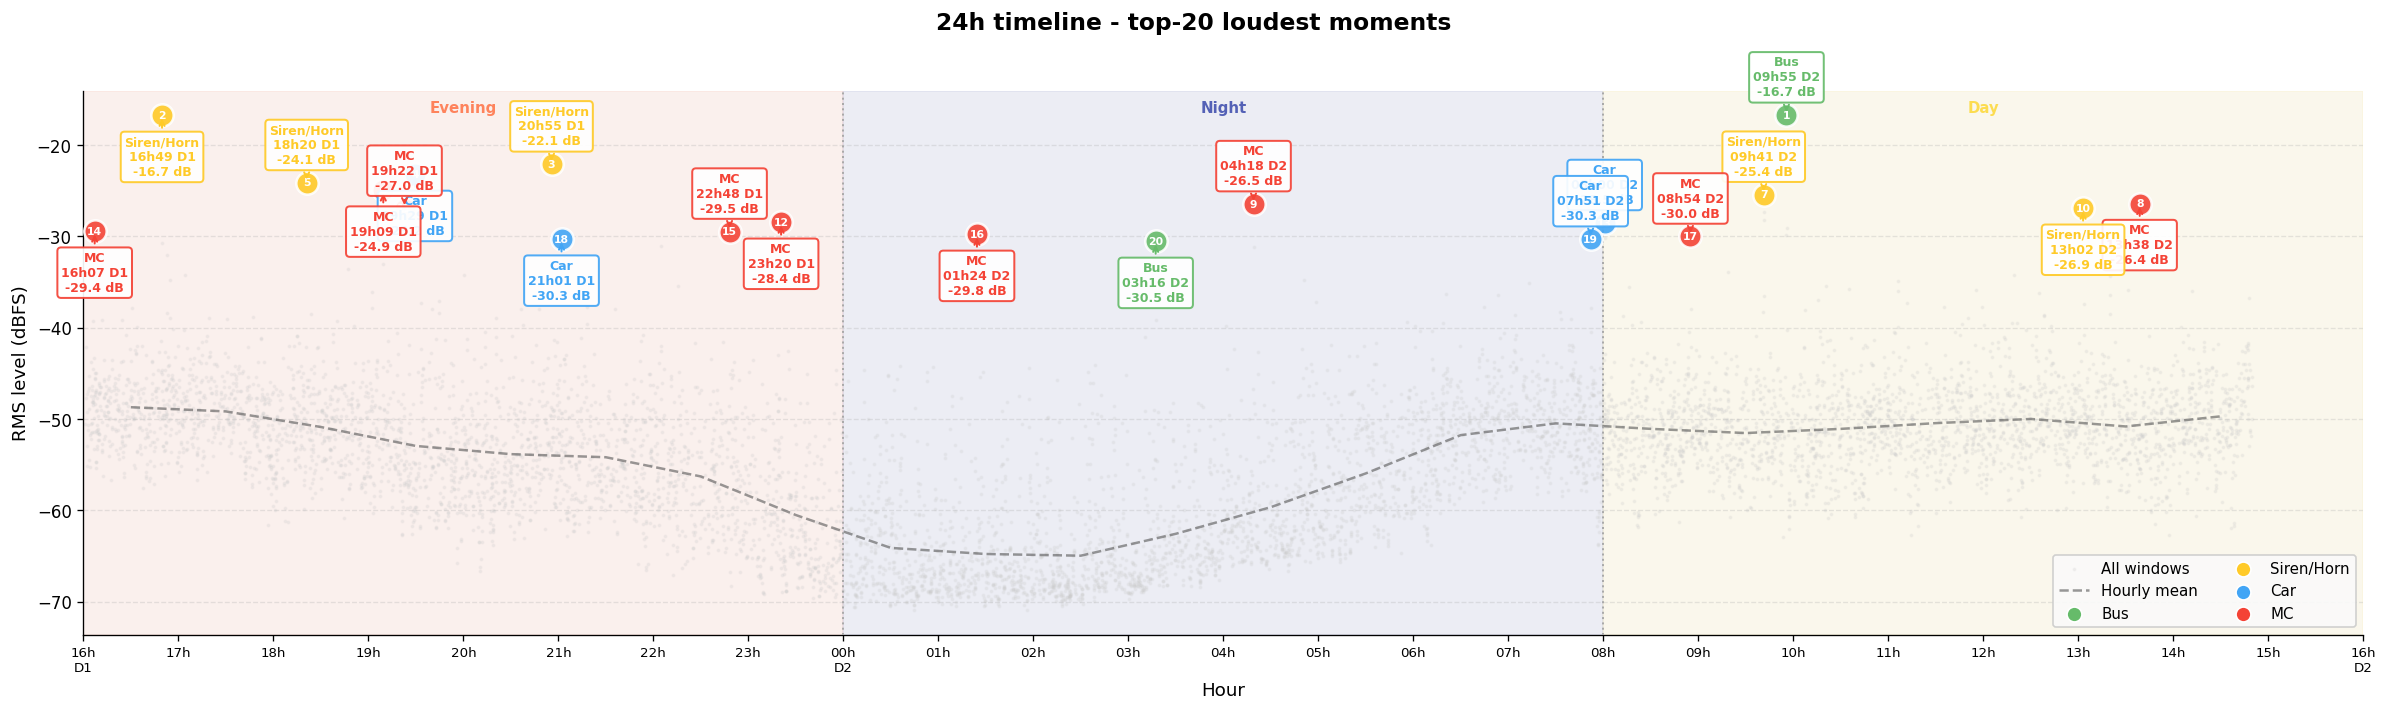

fig7_top20_timeline.png


In [17]:
CLASS_PEAK_COLORS = {
    'MC':           '#f44336',
    'Car':          '#42a5f5',
    'Bus':          '#66bb6a',
    'Truck':        '#ff7043',
    'Horn/Siren':   '#ffca28',
    'Dog':          '#26c6da',
    'Construction': '#8d6e63',
    'BG':           '#b0bec5',
}
CLASS_SHORT = {
    'MC': 'MC', 'Car': 'Car', 'Bus': 'Bus', 'Truck': 'Truck',
    'Horn/Siren': 'Siren/Horn', 'Dog': 'Dog',
    'Construction': 'Const.', 'BG': 'BG',
}


def normalize_class(cls):
    return 'Horn/Siren' if cls in ('Horn', 'Siren') else cls


fig, ax = plt.subplots(figsize=(20, 6))
fig.suptitle('24h timeline - top-20 loudest moments',
             fontsize=14, fontweight='bold')

for pname, ps, pe in period_ranges:
    ax.axvspan(ps, pe, color=PERIOD_COLORS[pname], alpha=0.07, zorder=0)
for xv in [24, 32]:
    ax.axvline(xv, color='#aaa', linewidth=1.2, linestyle=':', zorder=4)

sample = df_peaks.sample(min(8000, len(df_peaks)), random_state=42)
ax.scatter(sample['abs_hour'] + sample['t_peak'] / 3600, sample['db_peak'],
           c='#cccccc', s=2, alpha=0.18, zorder=1, label='All windows')

hourly_mean = (df_peaks
    .assign(hour_bin=df_peaks['abs_hour'].apply(lambda h: int(h)))
    .groupby('hour_bin')['db_peak'].mean()
    .reindex(range(16, 40)))
ax.plot(hourly_mean.index + 0.5, hourly_mean.values,
        color='#555', linewidth=1.5, linestyle='--', alpha=0.6,
        zorder=2, label='Hourly mean')

for rank, row in df_peaks_dedup.iterrows():
    x     = row['abs_hour'] + row['t_peak'] / 3600
    y     = row['db_peak']
    cls   = normalize_class(row['class_at_peak'])
    color = CLASS_PEAK_COLORS.get(cls, '#999')
    label = CLASS_SHORT.get(cls, cls)
    ax.scatter(x, y, s=180, color=color, zorder=6, alpha=0.9,
               edgecolors='white', linewidths=1.5)
    ax.text(x, y, str(rank + 1), ha='center', va='center',
            fontsize=6.5, fontweight='bold', color='white', zorder=7)
    offset_y = 1.8 if rank % 2 == 0 else -2.2
    va_side  = 'bottom' if rank % 2 == 0 else 'top'
    hh  = int(row['abs_hour']) % 24
    mm  = int((row['abs_hour'] % 1) * 60)
    day = 'D2' if row['abs_hour'] >= 24 else 'D1'
    ax.annotate(f"{label}\n{hh:02d}h{mm:02d} {day}\n{y:.1f} dB",
                xy=(x, y), xytext=(x, y + offset_y),
                ha='center', va=va_side, fontsize=7.5,
                fontweight='bold', color=color,
                arrowprops=dict(arrowstyle='->', color=color, lw=1.2),
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                          edgecolor=color, alpha=0.92, linewidth=1.2),
                zorder=8)

seen = set()
for _, row in df_peaks_dedup.iterrows():
    cls = normalize_class(row['class_at_peak'])
    if cls not in seen:
        color = CLASS_PEAK_COLORS.get(cls, '#999')
        ax.scatter([], [], s=80, color=color,
                   label=CLASS_SHORT.get(cls, cls).replace('\n', '/'),
                   edgecolors='white', linewidths=1)
        seen.add(cls)

ax.set_xticks(xticks); ax.set_xticklabels(xlabels, fontsize=8)
ax.set_xlim(16, 40); ax.set_ylabel('RMS level (dBFS)', fontsize=11)
ax.set_xlabel('Hour', fontsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.legend(loc='lower right', fontsize=9, ncol=2, framealpha=0.9)

ylo, yhi = ax.get_ylim()
for pname, ps, pe in period_ranges:
    ax.text((ps + pe) / 2, yhi - (yhi - ylo) * 0.04, pname,
            ha='center', fontsize=9, color=PERIOD_COLORS[pname],
            fontweight='bold', alpha=0.85)

plt.tight_layout()
plt.savefig('fig7_top20_timeline.png', dpi=150, bbox_inches='tight')
plt.show()
print("fig7_top20_timeline.png")

---
## 7. Vehicle noise analysis

### Fig 8 - dBFS distribution by vehicle class (violin plots)

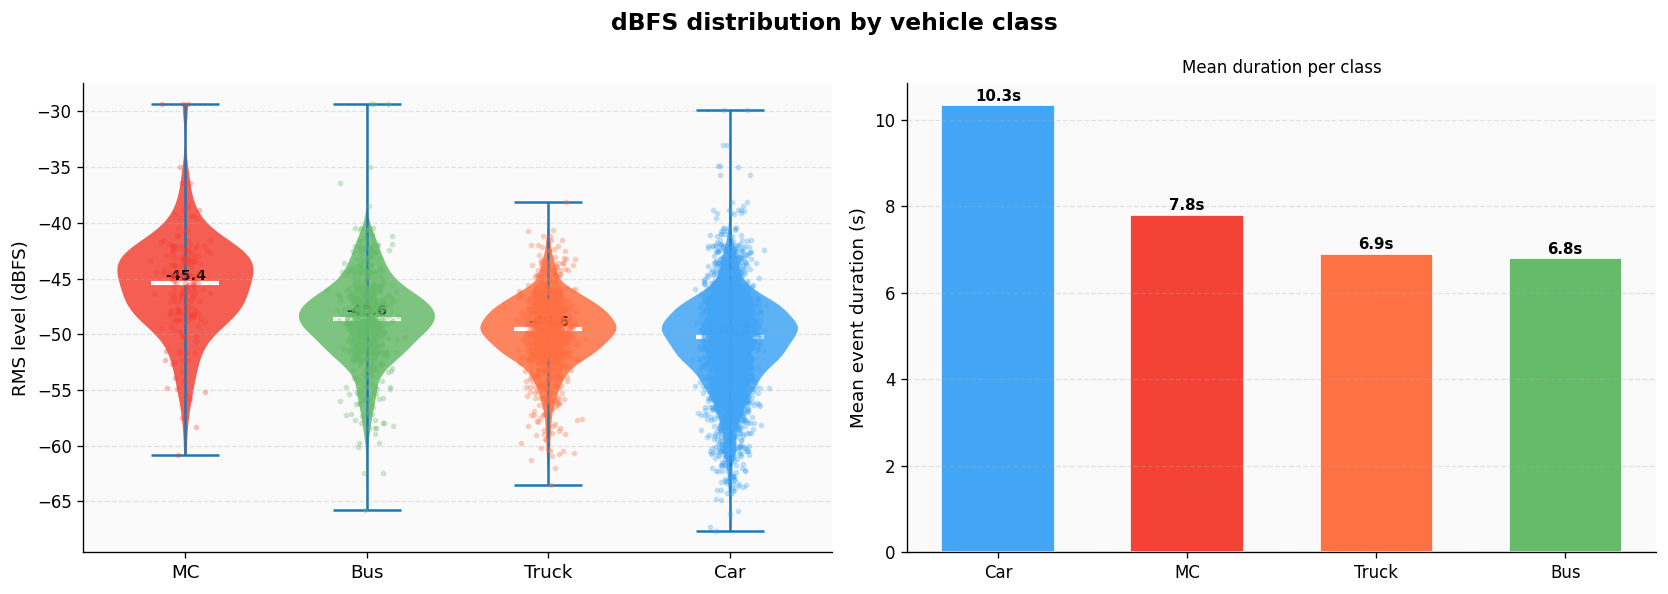

fig8_vehicle_noise.png


In [18]:
db_map = df_files.set_index('filename')['db_rms'].to_dict()
vehicle_events = df_events[df_events['class'].isin(VEHICLE_CLASSES)].copy()
vehicle_events['file_db'] = vehicle_events['filename'].map(db_map)

cls_order = (vehicle_events.groupby('class')['file_db']
             .median().sort_values(ascending=False).index.tolist())
data_vio  = [vehicle_events[vehicle_events['class'] == c]['file_db'].dropna().values
             for c in cls_order]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('dBFS distribution by vehicle class',
             fontsize=14, fontweight='bold')

ax = axes[0]
parts = ax.violinplot(data_vio, positions=range(len(cls_order)),
                      showmedians=True, showextrema=True, widths=0.75)
for body, cls in zip(parts['bodies'], cls_order):
    body.set_facecolor(CLASS_COLORS.get(cls, '#999')); body.set_alpha(0.85)
parts['cmedians'].set_color('white'); parts['cmedians'].set_linewidth(2.5)
for i, (d, cls) in enumerate(zip(data_vio, cls_order)):
    jitter = np.random.normal(0, 0.06, size=len(d))
    ax.scatter(np.full(len(d), i) + jitter, d, s=6, alpha=0.25,
               color=CLASS_COLORS.get(cls, '#999'), zorder=4)
    ax.text(i, np.median(d) + 0.3, f'{np.median(d):.1f}',
            ha='center', fontsize=8.5, fontweight='bold')
ax.set_xticks(range(len(cls_order))); ax.set_xticklabels(cls_order, fontsize=11)
ax.set_ylabel('RMS level (dBFS)', fontsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')

ax2 = axes[1]
cls_dur = vehicle_events.groupby('class')['duration'].mean().sort_values(ascending=False)
bars = ax2.bar(cls_dur.index, cls_dur.values,
               color=[CLASS_COLORS.get(c, '#999') for c in cls_dur.index],
               edgecolor='white', width=0.6)
for bar, val in zip(bars, cls_dur.values):
    ax2.text(bar.get_x() + bar.get_width() / 2, val + 0.1,
             f'{val:.1f}s', ha='center', fontsize=9, fontweight='bold')
ax2.set_ylabel('Mean event duration (s)', fontsize=11)
ax2.set_title('Mean duration per class', fontsize=10)
ax2.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('fig8_vehicle_noise.png', dpi=150, bbox_inches='tight')
plt.show()
print("fig8_vehicle_noise.png")

### Loudest vehicle per hour

In [19]:
VEHICLE_NOISE_CLASSES = ['Car', 'Truck', 'MC', 'Bus', 'Horn', 'Siren']


def normalize_vehicle(cls):
    return 'Siren/Horn' if cls in ('Horn', 'Siren') else cls


rows = []
for h in range(16, 40):
    sub = df[df['hour_bin'] == h].copy()
    if sub.empty:
        rows.append({'hour_bin': h, 'hour_label': abs_hour_label(h),
                     'loudest_vehicle': None, 'db_mean': np.nan})
        continue
    best_cls, best_db = None, -np.inf
    for cls in VEHICLE_NOISE_CLASSES:
        cls_col = f'n_{cls.lower()}'
        if cls_col not in sub.columns:
            continue
        sub_cls = sub[sub[cls_col] > 0]
        if sub_cls.empty:
            continue
        db_avg = sub_cls['db_rms'].mean()
        if db_avg > best_db:
            best_db  = db_avg; best_cls = cls
    rows.append({'hour_bin':        h,
                 'hour_label':      abs_hour_label(h),
                 'loudest_vehicle': normalize_vehicle(best_cls) if best_cls else None,
                 'db_mean':         best_db if best_cls else np.nan})

df_loudest = pd.DataFrame(rows)
print(f"{'Hour':<10} {'Loudest vehicle':<28} {'Mean dBFS':>10}")
print("-" * 50)
for _, row in df_loudest.iterrows():
    cls_str = row['loudest_vehicle'] if row['loudest_vehicle'] else "n/a"
    db_str  = f"{row['db_mean']:.1f}" if not np.isnan(row['db_mean']) else "n/a"
    print(f"{row['hour_label']:<10} {cls_str:<28} {db_str:>10}")

Hour       Loudest vehicle               Mean dBFS
--------------------------------------------------
16h D1     Siren/Horn                        -34.0
17h D1     MC                                -44.8
18h D1     Siren/Horn                        -41.8
19h D1     Siren/Horn                        -42.4
20h D1     Siren/Horn                        -45.6
21h D1     MC                                -45.0
22h D1     MC                                -46.4
23h D1     MC                                -49.3
00h D2     MC                                -42.1
01h D2     MC                                -47.5
02h D2     Truck                             -55.4
03h D2     Bus                               -54.1
04h D2     MC                                -47.4
05h D2     Bus                               -50.8
06h D2     MC                                -44.7
07h D2     Siren/Horn                        -46.1
08h D2     MC                                -44.8
09h D2     Siren/Horn          

### Comparative statistics by vehicle class

In [20]:
print("=" * 70)
print("  COMPARATIVE VEHICLE NOISE STATISTICS")
print("=" * 70)

stats_cls = vehicle_events.groupby('class')['file_db'].agg(
    Median='median',
    P10=lambda x: np.percentile(x.dropna(), 10),
    P90=lambda x: np.percentile(x.dropna(), 90),
    Mean='mean',
    N='count').sort_values('Median', ascending=False)
print("\n-- 1. dBFS levels per class (median / P10 / P90) --------------------")
print(stats_cls.round(1).to_string())

car_median = vehicle_events[vehicle_events['class'] == 'Car']['file_db'].median()
print(f"\n-- 2. % of events louder than Car median ({car_median:.1f} dBFS) --------")
for cls in VEHICLE_CLASSES:
    sub = vehicle_events[vehicle_events['class'] == cls]['file_db'].dropna()
    if len(sub) == 0:
        continue
    pct     = (sub > car_median).mean() * 100
    bar_len = int(pct / 5)
    bar     = '#' * bar_len + '.' * (20 - bar_len)
    print(f"  {cls:<8} {pct:>5.1f}%  {bar}  (n={len(sub)})")

mc_db  = vehicle_events[vehicle_events['class'] == 'MC']['file_db'].dropna()
car_db = vehicle_events[vehicle_events['class'] == 'Car']['file_db'].dropna()
if len(mc_db) > 5 and len(car_db) > 5:
    from scipy import stats as _stats
    t_stat, p_val = _stats.mannwhitneyu(mc_db, car_db, alternative='two-sided')
    sig = ('***' if p_val < 0.001 else '**' if p_val < 0.01
           else '*' if p_val < 0.05 else 'ns')
    print(f"\n-- 3. MC vs Car (Mann-Whitney U) ---------------------------------")
    print(f"  MC  median : {mc_db.median():.1f} dBFS  (n={len(mc_db)})")
    print(f"  Car median : {car_db.median():.1f} dBFS  (n={len(car_db)})")
    print(f"  p-value    : {p_val:.4f}  ({sig})")
    diff = mc_db.median() - car_db.median()
    direction = "louder" if diff > 0 else "quieter"
    print(f"  MC is {abs(diff):.1f} dB {direction} than Car in median.")

print("\n-- 4. Peak hour per class -------------------------------------------")
for cls in VEHICLE_CLASSES:
    sub = vehicle_events[vehicle_events['class'] == cls]
    if len(sub) == 0:
        continue
    peak_h = sub['abs_hour'].apply(lambda h: int(h)).value_counts().idxmax()
    n_peak = sub['abs_hour'].apply(lambda h: int(h)).value_counts().max()
    print(f"  {cls:<8} -> {abs_hour_label(peak_h):<12} "
          f"({n_peak} events - {get_period(peak_h)})")

print("\n-- 5. Night-time (00h-08h) share per class --------------------------")
total_by_cls = vehicle_events.groupby('class').size()
night_by_cls = vehicle_events[vehicle_events['period'] == 'Night'].groupby('class').size()
for cls in VEHICLE_CLASSES:
    tot   = total_by_cls.get(cls, 0)
    night = night_by_cls.get(cls, 0)
    pct   = night / tot * 100 if tot > 0 else 0
    bar   = '#' * int(pct / 5) + '.' * (20 - int(pct / 5))
    print(f"  {cls:<8} {pct:>5.1f}% at night  {bar}  ({night}/{tot})")
print("=" * 70)

  COMPARATIVE VEHICLE NOISE STATISTICS

-- 1. dBFS levels per class (median / P10 / P90) --------------------
       Median   P10   P90  Mean     N
class                                
MC      -45.4 -51.5 -41.5 -45.6   201
Bus     -48.6 -53.0 -44.2 -48.7   795
Truck   -49.6 -53.6 -46.4 -49.8  1294
Car     -50.2 -55.8 -46.4 -50.7  4813

-- 2. % of events louder than Car median (-50.2 dBFS) --------
  Car       50.0%  #########...........  (n=4813)
  Truck     60.0%  ###########.........  (n=1294)
  Bus       70.1%  ##############......  (n=795)
  MC        89.1%  #################...  (n=201)

-- 3. MC vs Car (Mann-Whitney U) ---------------------------------
  MC  median : -45.4 dBFS  (n=201)
  Car median : -50.2 dBFS  (n=4813)
  p-value    : 0.0000  (***)
  MC is 4.8 dB louder than Car in median.

-- 4. Peak hour per class -------------------------------------------
  Car      -> 13h D2       (270 events - Day)
  Truck    -> 08h D2       (111 events - Day)
  Bus      -> 11h D2       

---
## 8. Further figures

### Fig 9 - Precise Gantt timeline (second resolution)

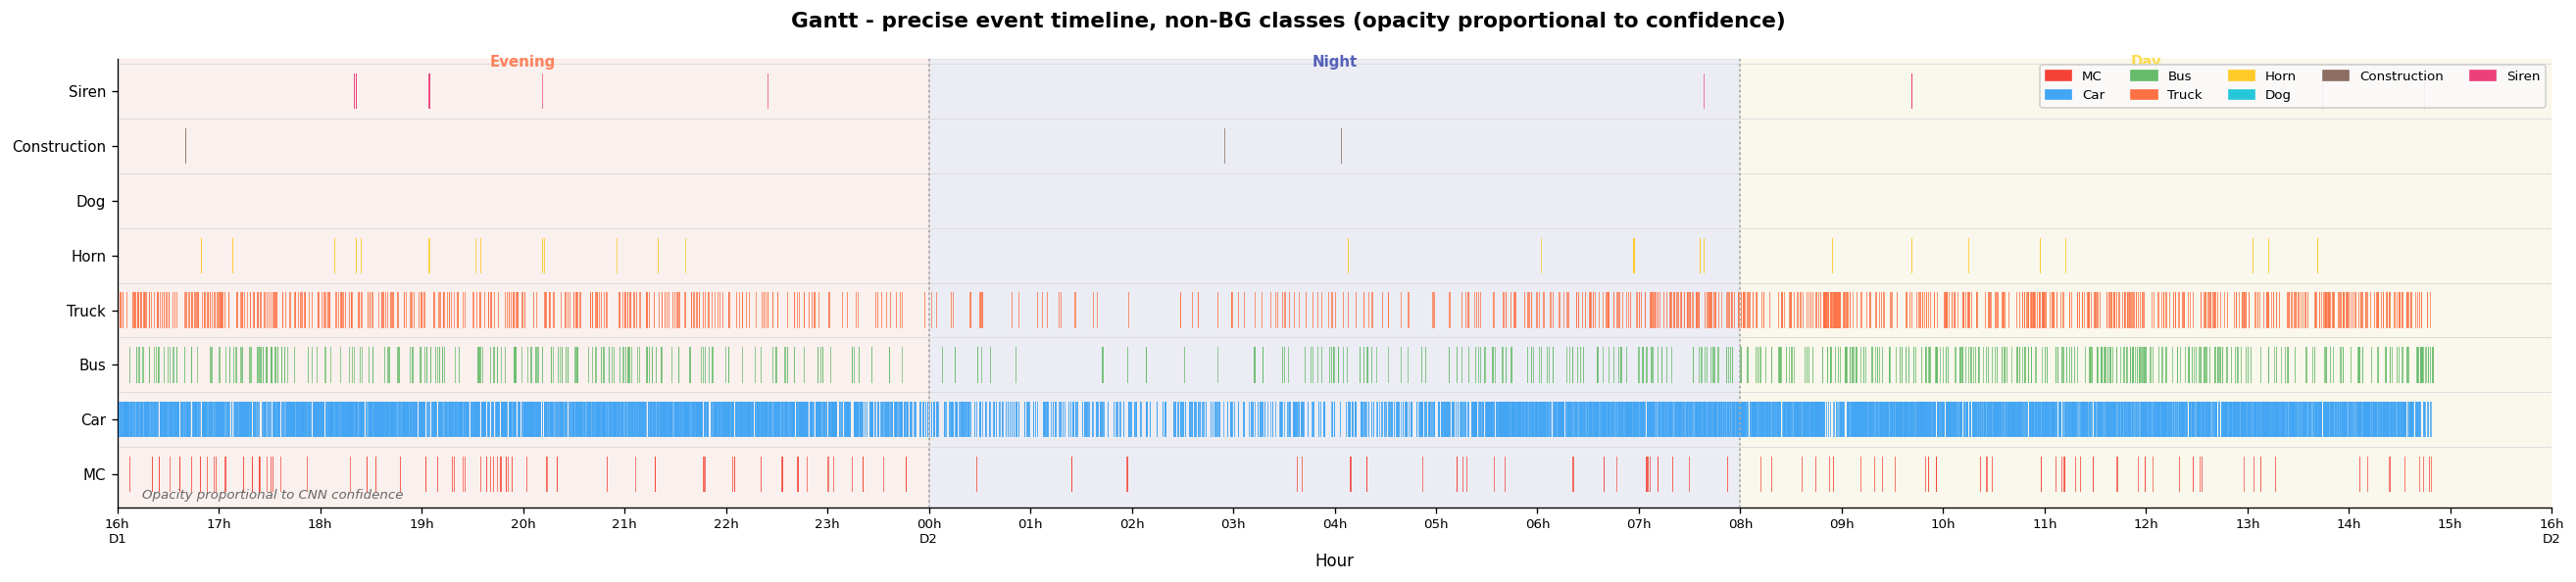

fig9_gantt.png


In [21]:
plot_ev = df_events[df_events['class'].isin(
    [c for c in CLASSES if c != 'BG'])].copy()
plot_ev['abs_t_start'] = plot_ev['abs_hour'] + plot_ev['t_start'] / 3600.0
plot_ev['abs_t_end']   = plot_ev['abs_hour'] + plot_ev['t_end']   / 3600.0
MIN_W = 0.5 / 60
plot_ev['width'] = (plot_ev['abs_t_end'] - plot_ev['abs_t_start']).clip(lower=MIN_W)

gantt_classes = [c for c in CLASSES if c != 'BG']
y_map = {cls: i for i, cls in enumerate(gantt_classes)}

fig, ax = plt.subplots(figsize=(22, 5))
fig.suptitle('Gantt - precise event timeline, non-BG classes '
             '(opacity proportional to confidence)',
             fontsize=13, fontweight='bold')

for pname, ps, pe in period_ranges:
    ax.axvspan(ps, pe, color=PERIOD_COLORS[pname], alpha=0.07, zorder=0)
for xv in [24, 32]:
    ax.axvline(xv, color='#aaa', linewidth=1.2, linestyle=':', zorder=4)

for _, row in plot_ev.iterrows():
    cls = row['class']
    if cls not in y_map:
        continue
    alpha = min(0.4 + row['conf_mean'] * 0.6, 1.0)
    ax.barh(y_map[cls], row['width'], left=row['abs_t_start'],
            height=0.65, color=CLASS_COLORS.get(cls, '#999'),
            alpha=alpha, edgecolor='none', zorder=3)

for y in range(len(gantt_classes)):
    ax.axhline(y + 0.5, color='#ddd', linewidth=0.6, zorder=2)

ax.set_yticks(list(y_map.values()))
ax.set_yticklabels(list(y_map.keys()), fontsize=9)
ax.set_xticks(xticks); ax.set_xticklabels(xlabels, fontsize=8)
ax.set_xlim(16, 40); ax.set_ylim(-0.6, len(gantt_classes) - 0.4)
ax.set_xlabel('Hour', fontsize=10)
ax.text(0.01, 0.02, 'Opacity proportional to CNN confidence',
        transform=ax.transAxes, fontsize=8, color='#666', style='italic')

ylo, yhi = ax.get_ylim()
for pname, ps, pe in period_ranges:
    ax.text((ps + pe) / 2, yhi - 0.15, pname, ha='center', fontsize=9,
            color=PERIOD_COLORS[pname], fontweight='bold', alpha=0.85)

handles = [mpatches.Patch(color=CLASS_COLORS.get(c, '#999'), label=c)
           for c in gantt_classes]
ax.legend(handles=handles, loc='upper right', ncol=5, fontsize=8, framealpha=0.9)

plt.tight_layout()
plt.savefig('fig9_gantt.png', dpi=150, bbox_inches='tight')
plt.show()
print("fig9_gantt.png")

### Fig 10 - dBFS vs vehicle traffic correlation by period

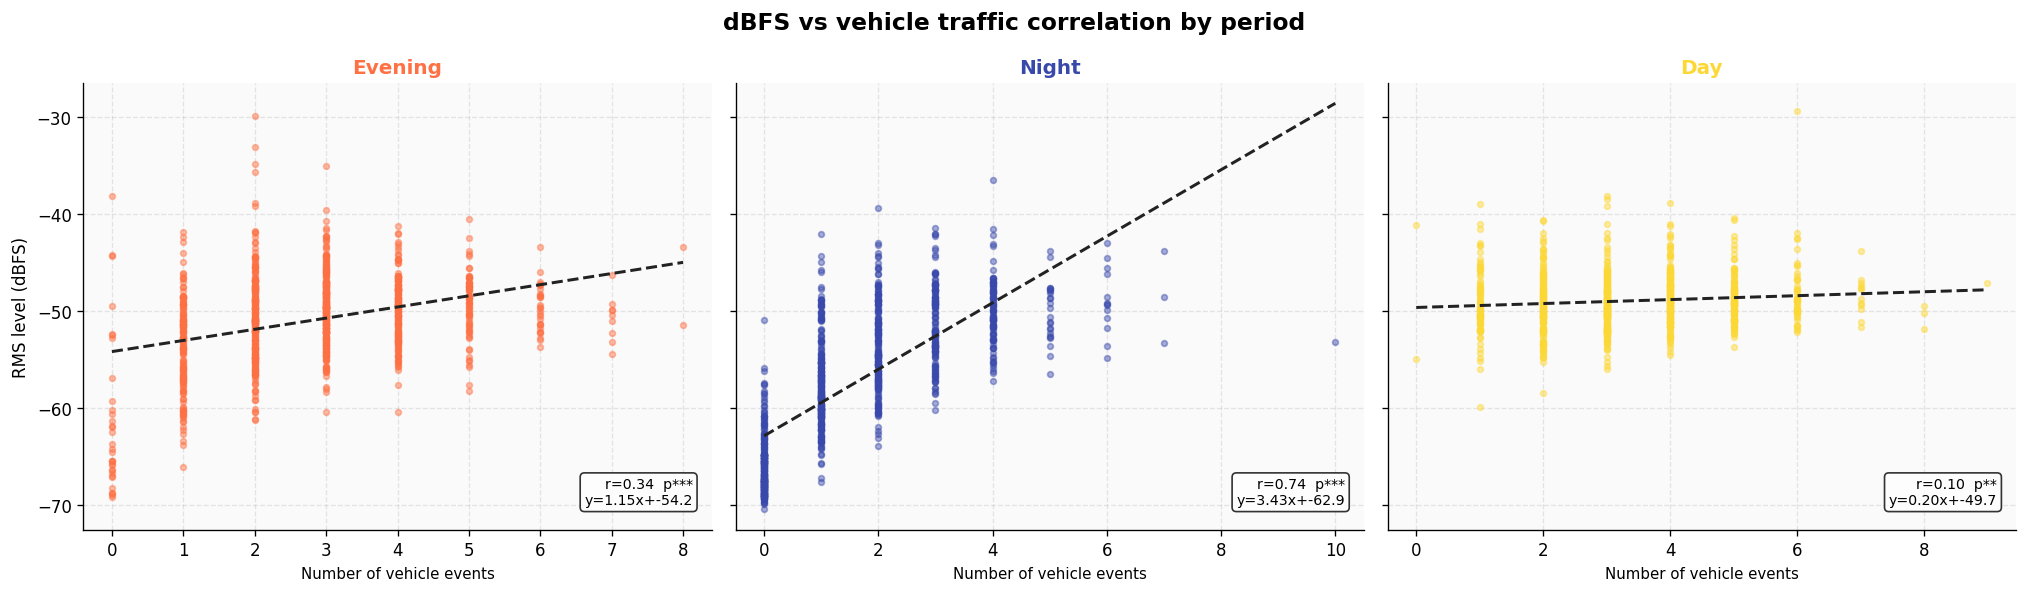

fig10_correlation.png


In [22]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True)
fig.suptitle('dBFS vs vehicle traffic correlation by period',
             fontsize=14, fontweight='bold')

for ax, period in zip(axes, ['Evening', 'Night', 'Day']):
    sub = df[df['period'] == period].dropna(subset=['db_rms', 'n_vehicles'])
    x, y = sub['n_vehicles'].values, sub['db_rms'].values
    ax.scatter(x, y, c=PERIOD_COLORS[period], s=12, alpha=0.45, zorder=3)
    if len(x) > 5 and x.std() > 0:
        slope, intercept, r, p, _ = stats.linregress(x, y)
        xfit = np.linspace(x.min(), x.max(), 100)
        ax.plot(xfit, slope * xfit + intercept,
                color='#222', linewidth=1.8, linestyle='--', zorder=5)
        sig = ('***' if p < 0.001 else '**' if p < 0.01
               else '*' if p < 0.05 else 'ns')
        ax.text(0.97, 0.05,
                f'r={r:.2f}  p{sig}\ny={slope:.2f}x+{intercept:.1f}',
                transform=ax.transAxes, ha='right', va='bottom', fontsize=8.5,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
    ax.set_title(period, fontsize=12, fontweight='bold',
                 color=PERIOD_COLORS[period])
    ax.set_xlabel('Number of vehicle events', fontsize=9)
    ax.grid(alpha=0.3, linestyle='--')

axes[0].set_ylabel('RMS level (dBFS)', fontsize=10)
plt.tight_layout()
plt.savefig('fig10_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("fig10_correlation.png")

### Fig 11 - Acoustic profile radar (events per file) by period

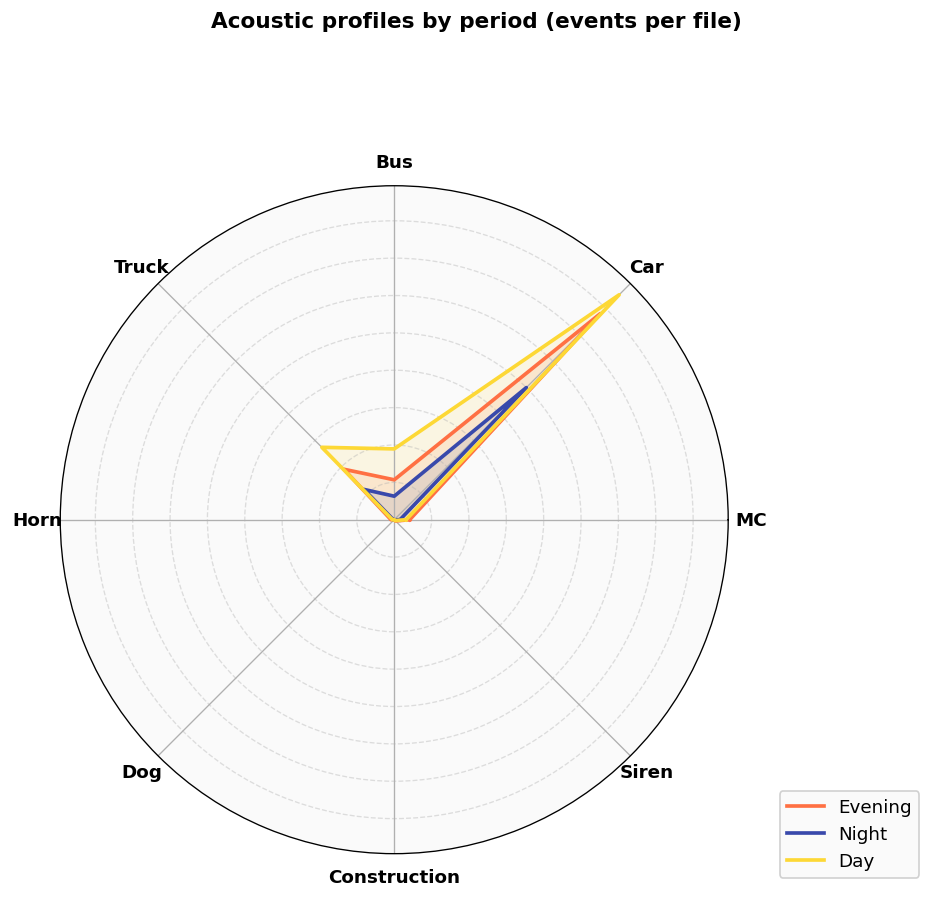

fig11_radar.png


In [23]:
radar_classes = [c for c in CLASSES if c != 'BG']
N_r    = len(radar_classes)
angles = np.linspace(0, 2 * np.pi, N_r, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
fig.suptitle('Acoustic profiles by period (events per file)',
             fontsize=13, fontweight='bold', y=1.01)

for period in ['Evening', 'Night', 'Day']:
    sub  = df_files[df_files['period'] == period]
    n_f  = max(len(sub), 1)
    vals = [sub[f'n_{c.lower()}'].sum() / n_f for c in radar_classes]
    vals += vals[:1]
    ax.plot(angles, vals, linewidth=2.2,
            color=PERIOD_COLORS[period], label=period)
    ax.fill(angles, vals, alpha=0.12, color=PERIOD_COLORS[period])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_classes, fontsize=11, fontweight='bold')
ax.set_yticklabels([])
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.legend(loc='lower right', bbox_to_anchor=(1.3, -0.05),
          fontsize=11, framealpha=0.9)

plt.tight_layout()
plt.savefig('fig11_radar.png', dpi=150, bbox_inches='tight')
plt.show()
print("fig11_radar.png")

### Fig 12 - 100% stacked area chart (raw counts + proportions)

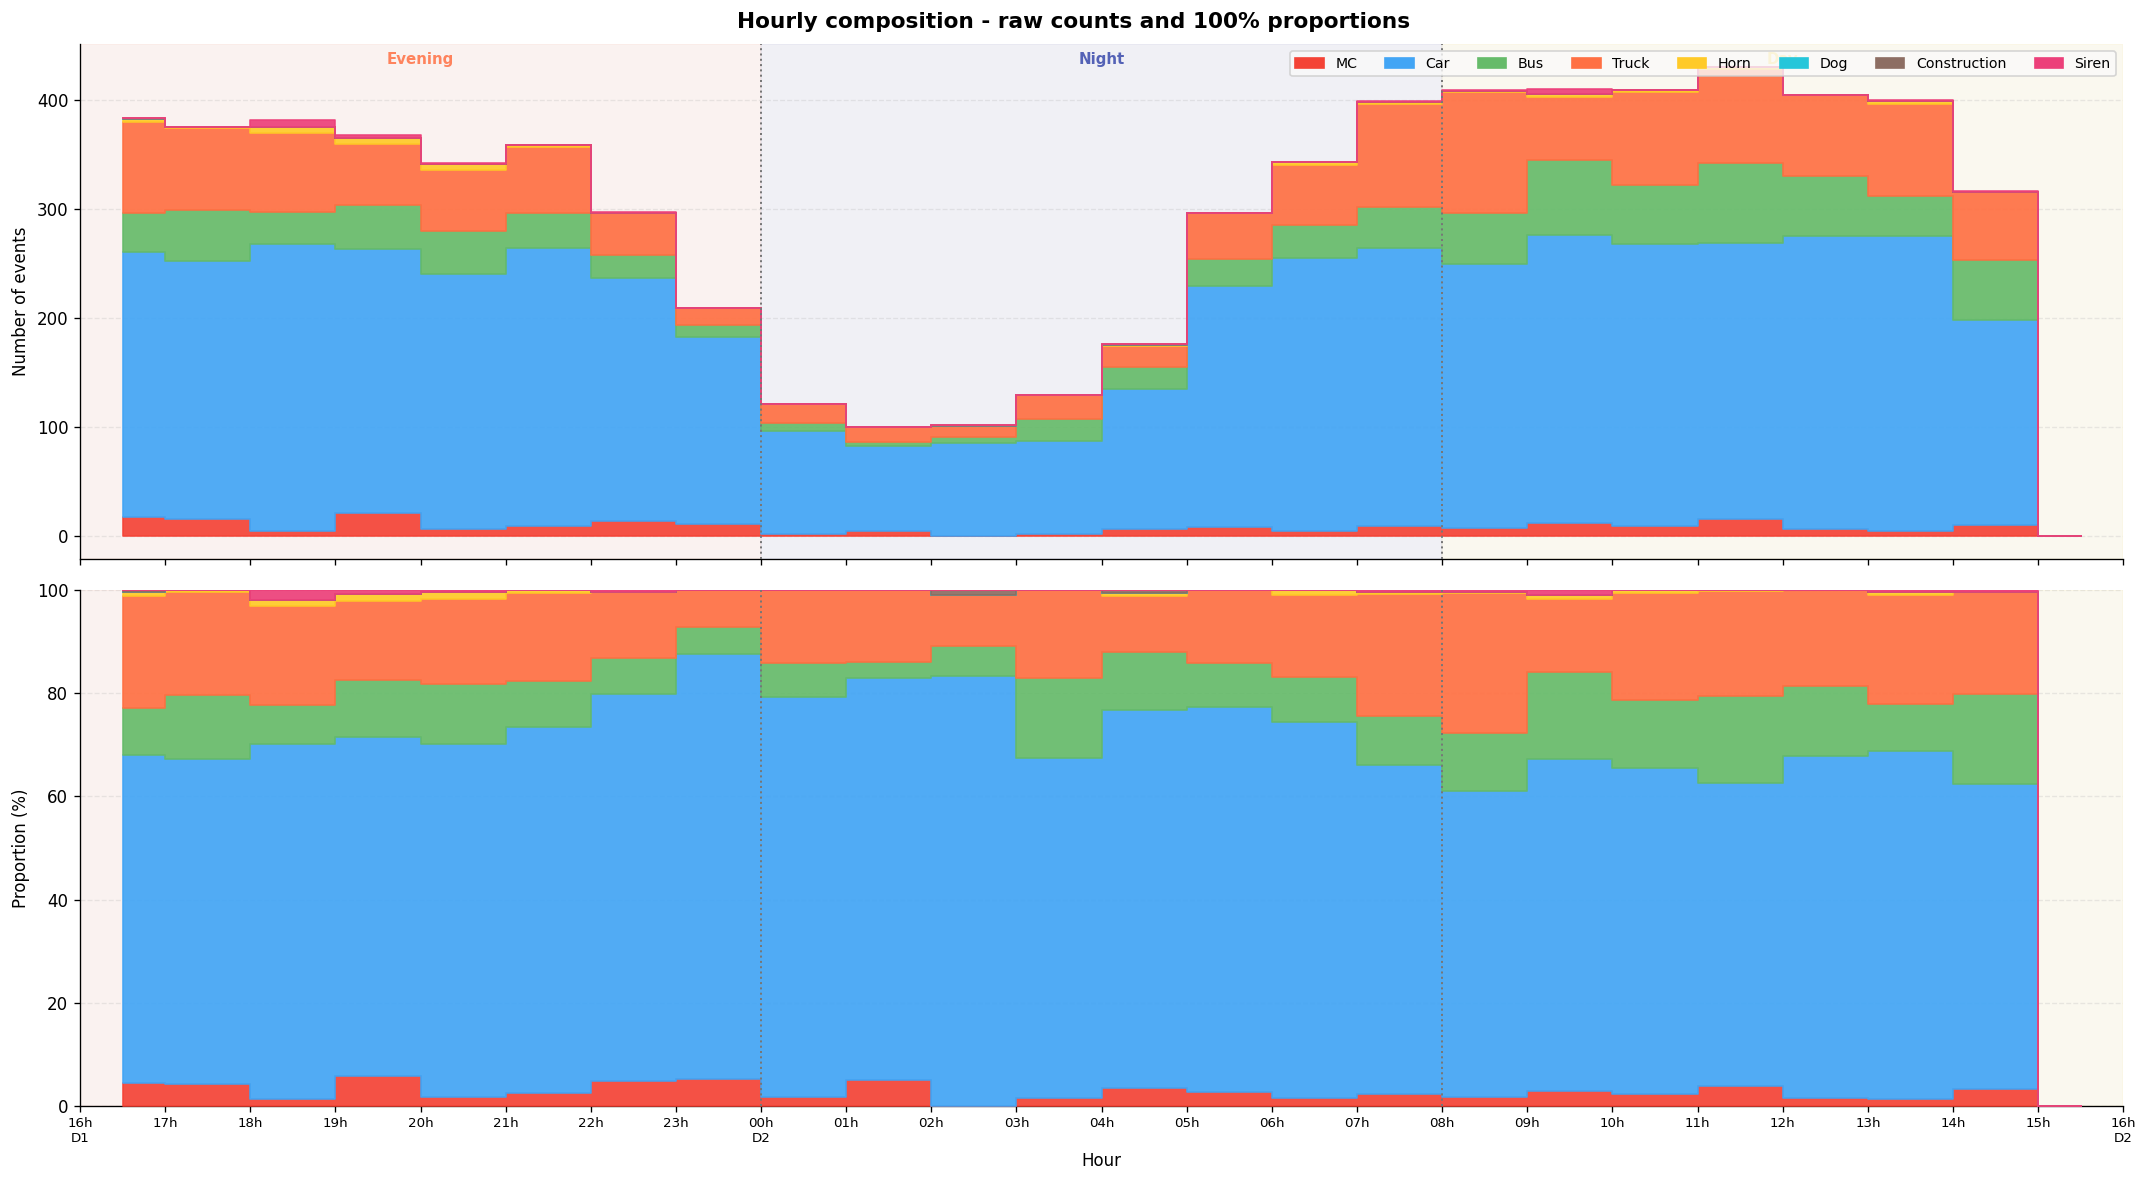

fig12_stacked_area.png


In [24]:
stack_classes = [c for c in CLASSES if c != 'BG']
stack_data    = np.zeros((len(stack_classes), 24))
for j, h in enumerate(range(16, 40)):
    for i, cls in enumerate(stack_classes):
        col = f'n_{cls.lower()}'
        row = df_hourly[df_hourly['hour_bin'] == h]
        if len(row) > 0 and col in row.columns:
            stack_data[i, j] = row[col].fillna(0).values[0]
        else:
            mask = df['hour_bin'] == h
            stack_data[i, j] = df.loc[mask, col].sum() if col in df.columns else 0

total_h    = stack_data.sum(axis=0)
stack_norm = np.where(total_h > 0, stack_data / total_h * 100, 0)
hb_s       = np.arange(16, 40) + 0.5

fig, axes = plt.subplots(2, 1, figsize=(18, 10), sharex=True)
fig.suptitle('Hourly composition - raw counts and 100% proportions',
             fontsize=13, fontweight='bold')

for ax, data, ylabel in [
    (axes[0], stack_data, 'Number of events'),
    (axes[1], stack_norm, 'Proportion (%)'),
]:
    bottom = np.zeros(24)
    for i, cls in enumerate(stack_classes):
        ax.fill_between(hb_s, bottom, bottom + data[i],
                        color=CLASS_COLORS.get(cls, '#999'), label=cls,
                        alpha=0.92, step='mid', zorder=3)
        bottom += data[i]
    for pname, ps, pe in period_ranges:
        ax.axvspan(ps, pe, color=PERIOD_COLORS[pname], alpha=0.05, zorder=0)
    for xv in [24, 32]:
        ax.axvline(xv, color='#777', linewidth=1.2, linestyle=':', zorder=5)
    ax.set_xlim(16, 40); ax.set_ylabel(ylabel, fontsize=10)
    ax.grid(axis='y', alpha=0.25, linestyle='--')

axes[1].set_xticks(xticks); axes[1].set_xticklabels(xlabels, fontsize=8)
axes[1].set_xlabel('Hour', fontsize=10); axes[1].set_ylim(0, 100)

handles = [mpatches.Patch(color=CLASS_COLORS.get(c, '#999'), label=c)
           for c in stack_classes]
axes[0].legend(handles=handles, loc='upper right',
               ncol=len(stack_classes), fontsize=8.5)

ylo, yhi = axes[0].get_ylim()
for pname, ps, pe in period_ranges:
    axes[0].text((ps + pe) / 2, yhi * 0.96, pname,
                 ha='center', fontsize=9, color=PERIOD_COLORS[pname],
                 fontweight='bold', alpha=0.85)

plt.tight_layout()
plt.savefig('fig12_stacked_area.png', dpi=150, bbox_inches='tight')
plt.show()
print("fig12_stacked_area.png")

### Fig 13 - CNN confidence over time

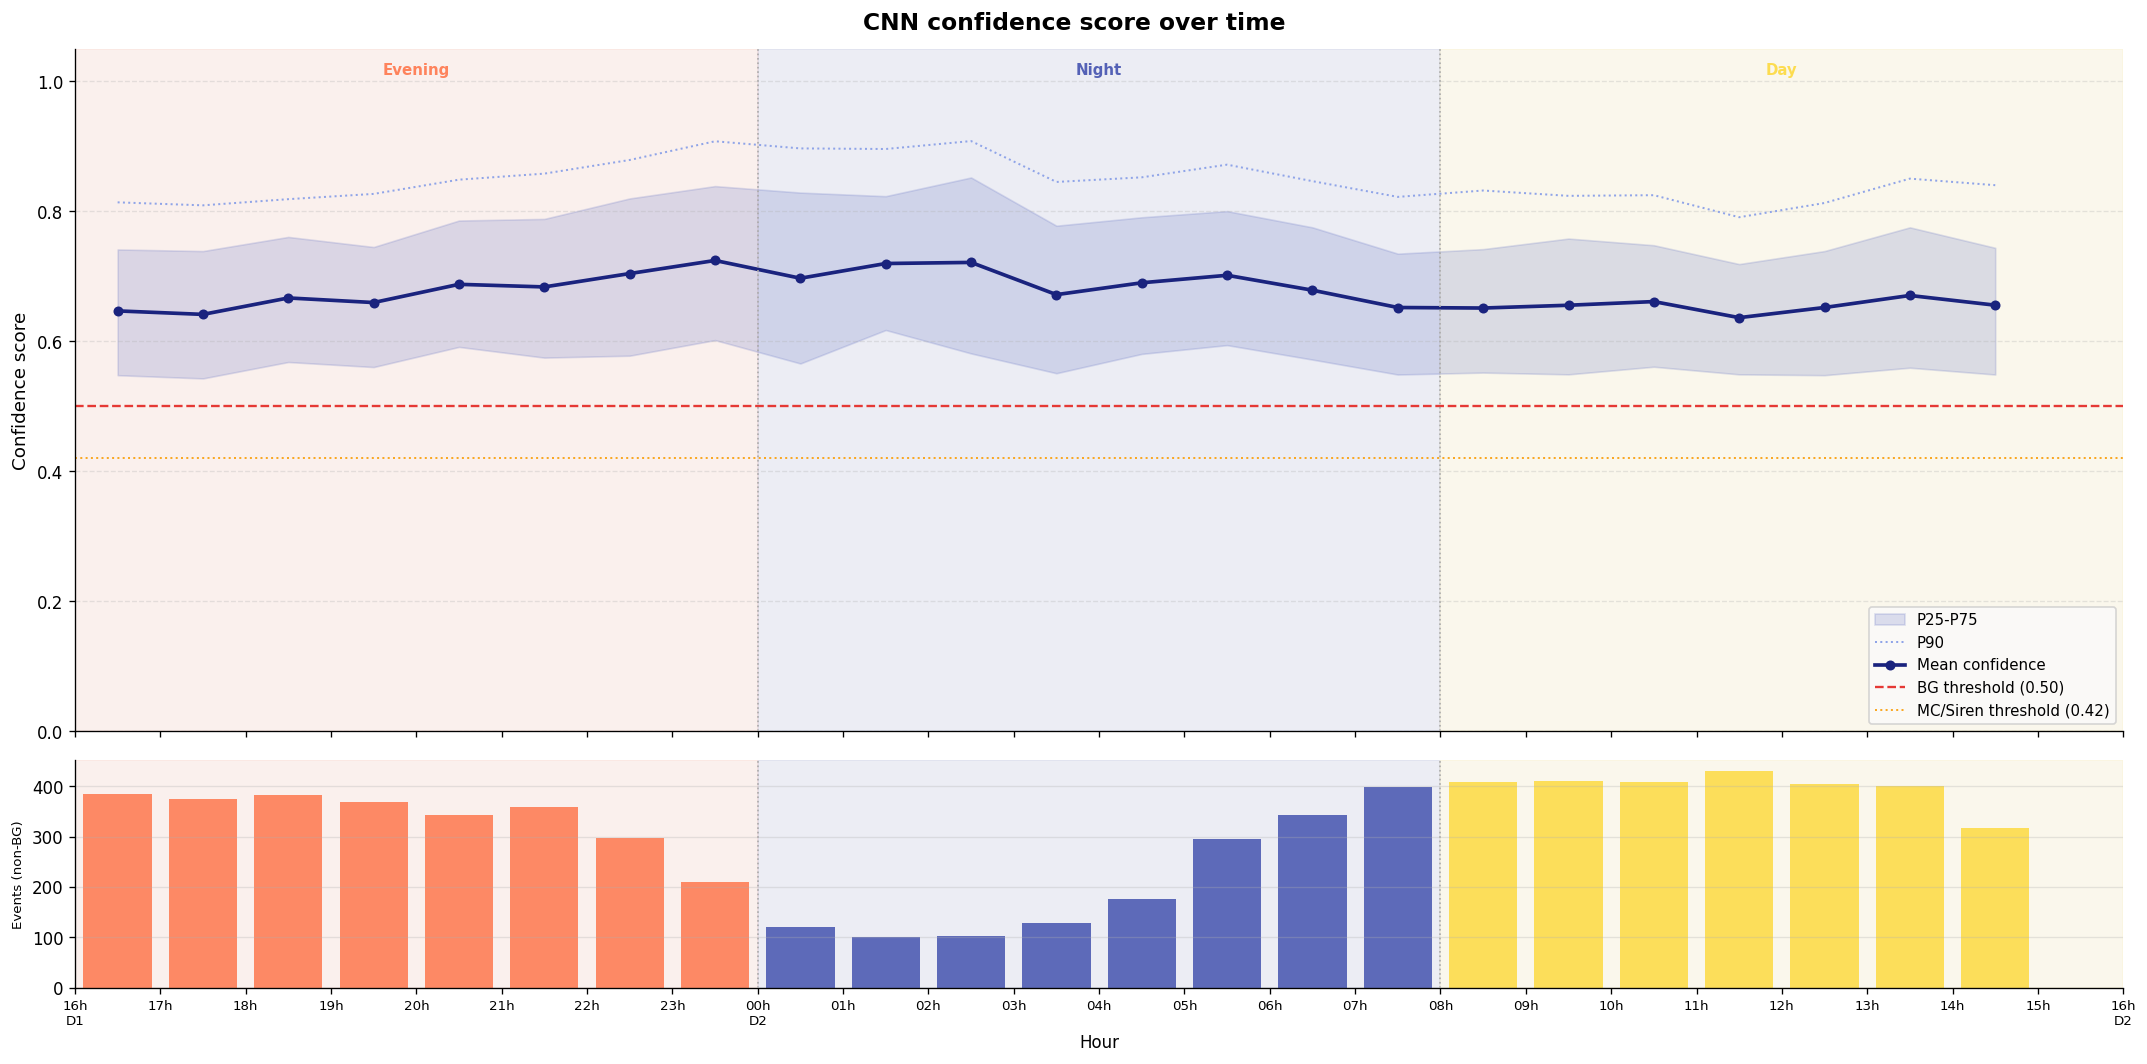

fig13_confidence.png


In [25]:
df_ev_nb = df_events[df_events['class'] != 'BG'].copy()
df_ev_nb['hour_bin'] = df_ev_nb['abs_hour'].apply(lambda h: int(h))

conf_hourly = df_ev_nb.groupby('hour_bin').agg(
    conf_mean=('conf_mean', 'mean'),
    conf_p25=('conf_mean', lambda x: np.percentile(x, 25)),
    conf_p75=('conf_mean', lambda x: np.percentile(x, 75)),
    conf_p90=('conf_mean', lambda x: np.percentile(x, 90)),
    n_events=('conf_mean', 'count'),
).reset_index().set_index('hour_bin').reindex(range(16, 40)).reset_index()
conf_hourly['period'] = conf_hourly['hour_bin'].apply(get_period)

fig, axes = plt.subplots(2, 1, figsize=(18, 9), sharex=True,
                          gridspec_kw={'height_ratios': [3, 1]})
fig.suptitle('CNN confidence score over time', fontsize=14, fontweight='bold')

ax   = axes[0]
hb_c = conf_hourly['hour_bin'] + 0.5
add_period_bg(ax)
ax.fill_between(hb_c, conf_hourly['conf_p25'], conf_hourly['conf_p75'],
                alpha=0.20, color='#5c6bc0', label='P25-P75')
ax.plot(hb_c, conf_hourly['conf_p90'],
        color='#8fa4e8', linewidth=1.2, linestyle=':', label='P90')
ax.plot(hb_c, conf_hourly['conf_mean'],
        color='#1a237e', linewidth=2.2, marker='o', markersize=5,
        label='Mean confidence')
ax.axhline(0.50, color='#e53935', linewidth=1.4, linestyle='--',
           label='BG threshold (0.50)')
ax.axhline(0.42, color='#f9a825', linewidth=1.2, linestyle=':',
           label='MC/Siren threshold (0.42)')

low_conf = conf_hourly[conf_hourly['conf_mean'].fillna(1.0) < 0.60]
for _, row in low_conf.iterrows():
    ax.annotate('!', xy=(row['hour_bin'] + 0.5, row['conf_mean']),
                fontsize=13, color='#e53935', ha='center', va='bottom', zorder=7)

ax.set_ylim(0, 1.05); ax.set_ylabel('Confidence score', fontsize=11)
ax.legend(loc='lower right', fontsize=9)
ax.grid(axis='y', alpha=0.3, linestyle='--')

ylo, yhi = ax.get_ylim()
for pname, ps, pe in period_ranges:
    ax.text((ps + pe) / 2, yhi - 0.04, pname,
            ha='center', fontsize=9, color=PERIOD_COLORS[pname],
            fontweight='bold', alpha=0.85)

ax2 = axes[1]
bar_colors = [PERIOD_COLORS.get(get_period(h), '#888')
              for h in conf_hourly['hour_bin'].values]
ax2.bar(conf_hourly['hour_bin'] + 0.5, conf_hourly['n_events'].fillna(0),
        width=0.8, color=bar_colors, alpha=0.8)
add_period_bg(ax2)
ax2.set_ylabel('Events (non-BG)', fontsize=8)
ax2.grid(axis='y', alpha=0.3)
ax2.set_xticks(xticks); ax2.set_xticklabels(xlabels, fontsize=8)
ax2.set_xlim(16, 40); ax2.set_xlabel('Hour', fontsize=10)

plt.tight_layout()
plt.savefig('fig13_confidence.png', dpi=150, bbox_inches='tight')
plt.show()
print("fig13_confidence.png")

### Fig 14 - dBFS boxplot by class x period and hourly activity

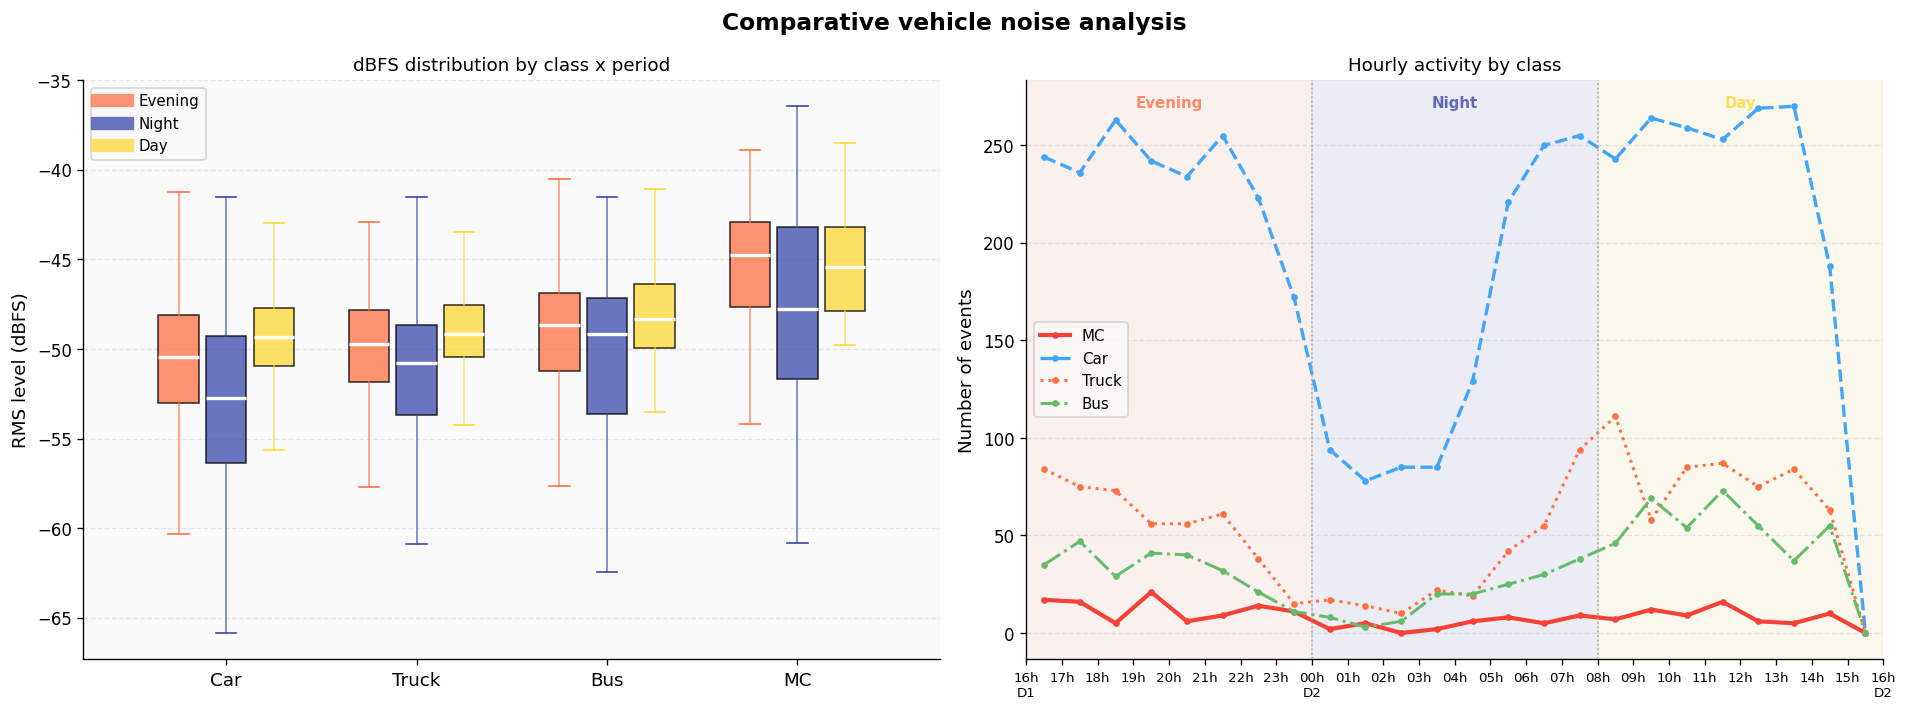

fig14_boxplot_activity.png


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Comparative vehicle noise analysis',
             fontsize=14, fontweight='bold')

ax = axes[0]
x_positions = np.arange(len(VEHICLE_CLASSES))
width   = 0.25
offsets = [-width, 0, width]
for offset, period in zip(offsets, ['Evening', 'Night', 'Day']):
    for i, cls in enumerate(VEHICLE_CLASSES):
        sub = vehicle_events[
            (vehicle_events['class'] == cls) &
            (vehicle_events['period'] == period)]['file_db'].dropna()
        if len(sub) > 1:
            ax.boxplot(sub, positions=[i + offset], widths=width * 0.85,
                       patch_artist=True, showfliers=False,
                       medianprops=dict(color='white', linewidth=2),
                       whiskerprops=dict(color=PERIOD_COLORS[period], alpha=0.7),
                       capprops=dict(color=PERIOD_COLORS[period]),
                       boxprops=dict(facecolor=PERIOD_COLORS[period], alpha=0.75))

ax.set_xticks(x_positions); ax.set_xticklabels(VEHICLE_CLASSES, fontsize=11)
ax.set_ylabel('RMS level (dBFS)', fontsize=11)
ax.set_title('dBFS distribution by class x period', fontsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')
for period in ['Evening', 'Night', 'Day']:
    ax.plot([], [], color=PERIOD_COLORS[period],
            linewidth=8, alpha=0.75, label=period)
ax.legend(fontsize=9)

ax2 = axes[1]
for cls, lw, ls in [('MC', 2.5, '-'), ('Car', 2.0, '--'),
                    ('Truck', 1.8, ':'), ('Bus', 1.8, '-.')]:
    sub = vehicle_events[vehicle_events['class'] == cls].copy()
    if len(sub) == 0:
        continue
    hour_counts = (sub.groupby(sub['abs_hour'].apply(lambda h: int(h)))
                      .size().reindex(range(16, 40), fill_value=0))
    ax2.plot(hour_counts.index + 0.5, hour_counts.values,
             color=CLASS_COLORS[cls], linewidth=lw, linestyle=ls,
             label=cls, marker='o', markersize=3)

for pname, ps, pe in period_ranges:
    ax2.axvspan(ps, pe, color=PERIOD_COLORS[pname], alpha=0.07, zorder=0)
for xv in [24, 32]:
    ax2.axvline(xv, color='#aaa', linewidth=1, linestyle=':', zorder=4)
ax2.set_xticks(xticks); ax2.set_xticklabels(xlabels, fontsize=8)
ax2.set_xlim(16, 40); ax2.set_ylabel('Number of events', fontsize=11)
ax2.set_title('Hourly activity by class', fontsize=11)
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.legend(fontsize=9)

ylo, yhi = ax2.get_ylim()
for pname, ps, pe in period_ranges:
    ax2.text((ps + pe) / 2, yhi * 0.95, pname, ha='center', fontsize=9,
             color=PERIOD_COLORS[pname], fontweight='bold', alpha=0.8)

plt.tight_layout()
plt.savefig('fig14_boxplot_activity.png', dpi=150, bbox_inches='tight')
plt.show()
print("fig14_boxplot_activity.png")

---
## 9. Interactive audio player

Single reusable widget. Use the **class toggle** to browse events by class,
the **sort dropdown** to reorder by confidence, dBFS, or chronology, and
the navigation buttons to step through files. The mel-spectrogram panel
highlights detected event segments in the class color.

In [ ]:
ALL_CLASSES  = [c for c in CLASSES if c != 'BG']
SORT_OPTIONS = {
    "Confidence desc (best detections)": ("conf_mean", False),
    "Confidence asc (ambiguous cases)":  ("conf_mean", True),
    "dBFS desc (loudest)":               ("db_rms",    False),
    "dBFS asc (quietest)":               ("db_rms",    True),
    "Chronological":                     ("abs_hour",  True),
    "Event count desc":                  ("n_events",  False),
}

# Build per-class file index once
class_file_index = {}
for cls in ALL_CLASSES:
    sub = (df_events[df_events['class'] == cls]
           .groupby('filename')
           .agg(abs_hour=('abs_hour',  'first'),
                period   =('period',    'first'),
                conf_mean=('conf_mean', 'mean'),
                n_events =('class',     'count'),
                t_starts =('t_start',   list),
                t_ends   =('t_end',     list))
           .reset_index()
           .sort_values('conf_mean', ascending=False))
    sub['db_rms'] = sub['filename'].map(db_map)
    class_file_index[cls] = sub


def show_audio_file(fname, cls):
    """Render info panel, audio player, and mel-spectrogram for fname/cls."""
    folder = get_folder(fname)
    with info_out:
        clear_output(wait=True)
        row_f = df_files[df_files['filename'] == fname]
        row_e = df_events[(df_events['filename'] == fname) &
                          (df_events['class'] == cls)]
        abs_h  = row_f['abs_hour'].values[0] if len(row_f) else 0
        db_val = row_f['db_rms'].values[0]   if len(row_f) else float('nan')
        print(f"File   : {fname}")
        print(f"Time   : {abs_hour_label(abs_h)}   Level: {db_val:.1f} dBFS")
        print(f"Class  : {cls} - {len(row_e)} event(s)")
        for _, e in row_e.iterrows():
            bar = '#' * int(e['conf_mean'] * 20) + '.' * (20 - int(e['conf_mean'] * 20))
            print(f"  {e['t_start']:>5.1f}s -> {e['t_end']:>5.1f}s  "
                  f"conf={e['conf_mean']:.0%}  {bar}")
        if folder is None:
            print("WARNING: audio file not found on disk.")
    with audio_out:
        clear_output(wait=True)
        if folder is None:
            return
        audio, _sr = librosa.load(str(folder / fname), sr=SR, mono=True)
        display(Audio(audio, rate=SR, autoplay=False))
    with plot_out:
        clear_output(wait=True)
        if folder is None:
            return
        audio, _sr = librosa.load(str(folder / fname), sr=SR, mono=True)
        row_e = df_events[(df_events['filename'] == fname) &
                          (df_events['class'] == cls)]
        fig, axs = plt.subplots(2, 1, figsize=(14, 4),
                                gridspec_kw={'height_ratios': [3, 1]})
        S    = librosa.feature.melspectrogram(y=audio, sr=SR, n_fft=1024,
                                              hop_length=512, n_mels=64,
                                              fmin=50, fmax=8000, power=2.0)
        S_db = librosa.power_to_db(S, ref=np.max)
        librosa.display.specshow(S_db, sr=SR, hop_length=512,
                                 x_axis='time', y_axis='mel',
                                 fmin=50, fmax=8000, ax=axs[0], cmap='magma')
        axs[0].set_title(f'Mel spectrogram - {fname}',
                         fontsize=10, fontweight='bold')
        axs[0].set_xlabel('')
        _, yhi_s = axs[0].get_ylim()
        for _, e in row_e.iterrows():
            axs[0].axvspan(e['t_start'], e['t_end'],
                           color=CLASS_COLORS.get(cls, '#fff'),
                           alpha=0.25, zorder=4)
            axs[0].text((e['t_start'] + e['t_end']) / 2, yhi_s * 0.92,
                        f"{e['conf_mean']:.0%}", ha='center', va='top',
                        fontsize=8, color='white', fontweight='bold', zorder=5)
        dur = len(audio) / SR
        axs[1].set_xlim(0, dur); axs[1].set_ylim(0, 1)
        for _, e in row_e.iterrows():
            axs[1].barh(0.5, e['t_end'] - e['t_start'], left=e['t_start'],
                        height=0.6, color=CLASS_COLORS.get(cls, '#999'),
                        alpha=min(0.3 + e['conf_mean'] * 0.7, 1.0), zorder=3)
        axs[1].set_yticks([])
        axs[1].set_xlabel('Time (s)', fontsize=9)
        axs[1].spines[['top', 'left']].set_visible(False)
        plt.tight_layout(); plt.show()


# ── Widgets ───────────────────────────────────────────────────────────────────
style_w = {'description_width': 'initial'}

class_sel = widgets.ToggleButtons(
    options=ALL_CLASSES, description='Class:',
    style={'description_width': 'initial', 'button_width': '90px'})
sort_sel  = widgets.Dropdown(
    options=list(SORT_OPTIONS.keys()), description='Sort by:', style=style_w,
    layout=widgets.Layout(width='55%'))
file_sel  = widgets.Dropdown(
    options=[], description='File:', style=style_w,
    layout=widgets.Layout(width='95%'))
prev_btn  = widgets.Button(description='< Previous',
                           layout=widgets.Layout(width='120px'))
next_btn  = widgets.Button(description='Next >',
                           layout=widgets.Layout(width='120px'))
rand_btn  = widgets.Button(description='Random', button_style='info',
                           layout=widgets.Layout(width='120px'))
counter   = widgets.Label(value='')
info_out  = widgets.Output()
audio_out = widgets.Output()
plot_out  = widgets.Output()


def build_options(cls, sort_key):
    col, asc = SORT_OPTIONS[sort_key]
    df_cls = class_file_index[cls].sort_values(col, ascending=asc)
    return [(f"{r['filename']}  [{abs_hour_label(r['abs_hour'])} / {r['period']}]"
             f"  conf={r['conf_mean']:.0%}  {r['db_rms']:.1f}dB  {int(r['n_events'])} evt",
             r['filename']) for _, r in df_cls.iterrows()]


def update_files(cls, sort_key):
    opts = build_options(cls, sort_key)
    with file_sel.hold_trait_notifications():
        file_sel.options = opts
    counter.value = f"1 / {len(opts)}" if opts else "0 / 0"


def on_class(c):  update_files(c['new'], sort_sel.value)
def on_sort(c):   update_files(class_sel.value, c['new'])


def on_file(c):
    if c['new'] is None:
        return
    vals = [o[1] if isinstance(o, tuple) else o for o in file_sel.options]
    idx  = vals.index(c['new']) + 1 if c['new'] in vals else '?'
    counter.value = f"{idx} / {len(vals)}"
    show_audio_file(c['new'], class_sel.value)


def on_next(b):
    opts = [o[1] if isinstance(o, tuple) else o for o in file_sel.options]
    if not opts: return
    cur = file_sel.value
    file_sel.value = (opts[(opts.index(cur) + 1) % len(opts)]
                      if cur in opts else opts[0])


def on_prev(b):
    opts = [o[1] if isinstance(o, tuple) else o for o in file_sel.options]
    if not opts: return
    cur = file_sel.value
    file_sel.value = (opts[(opts.index(cur) - 1) % len(opts)]
                      if cur in opts else opts[0])


def on_rand(b):
    opts = [o[1] if isinstance(o, tuple) else o for o in file_sel.options]
    if opts:
        file_sel.value = opts[np.random.randint(len(opts))]


class_sel.observe(on_class, names='value')
sort_sel.observe(on_sort,   names='value')
file_sel.observe(on_file,   names='value')
next_btn.on_click(on_next)
prev_btn.on_click(on_prev)
rand_btn.on_click(on_rand)

controls = widgets.HBox(
    [prev_btn, next_btn, rand_btn, counter],
    layout=widgets.Layout(align_items='center', gap='8px'))
header = widgets.VBox(
    [widgets.HTML("<h3 style='margin:0'>Interactive audio player</h3>"),
     class_sel, sort_sel, file_sel, controls],
    layout=widgets.Layout(gap='6px'))

display(widgets.VBox([
    header,
    widgets.HBox([
        widgets.VBox([info_out],  layout=widgets.Layout(width='45%')),
        widgets.VBox([audio_out], layout=widgets.Layout(width='55%')),
    ], layout=widgets.Layout(gap='12px')),
    plot_out,
]))

update_files(ALL_CLASSES[0], sort_sel.value)
if file_sel.options:
    first = file_sel.options[0]
    show_audio_file(first[1] if isinstance(first, tuple) else first, ALL_CLASSES[0])

---
## 11. Top-N loudest peaks — class distribution and annotated timeline

### Fig 15 – Vehicle class distribution (pie) and 24h timeline for the 20 / 50 / 100 loudest peaks

Three rows: each row pairs the class breakdown of the N loudest de-duplicated peaks
(left, pie chart) with their positions overlaid on the 24h sound-level timeline (right).
Full text annotations are shown for top-20; numbered dots only for top-50 and top-100
to avoid crowding.

Building top-50 and top-100 peak lists (reuses top-20 labels)...
Done.


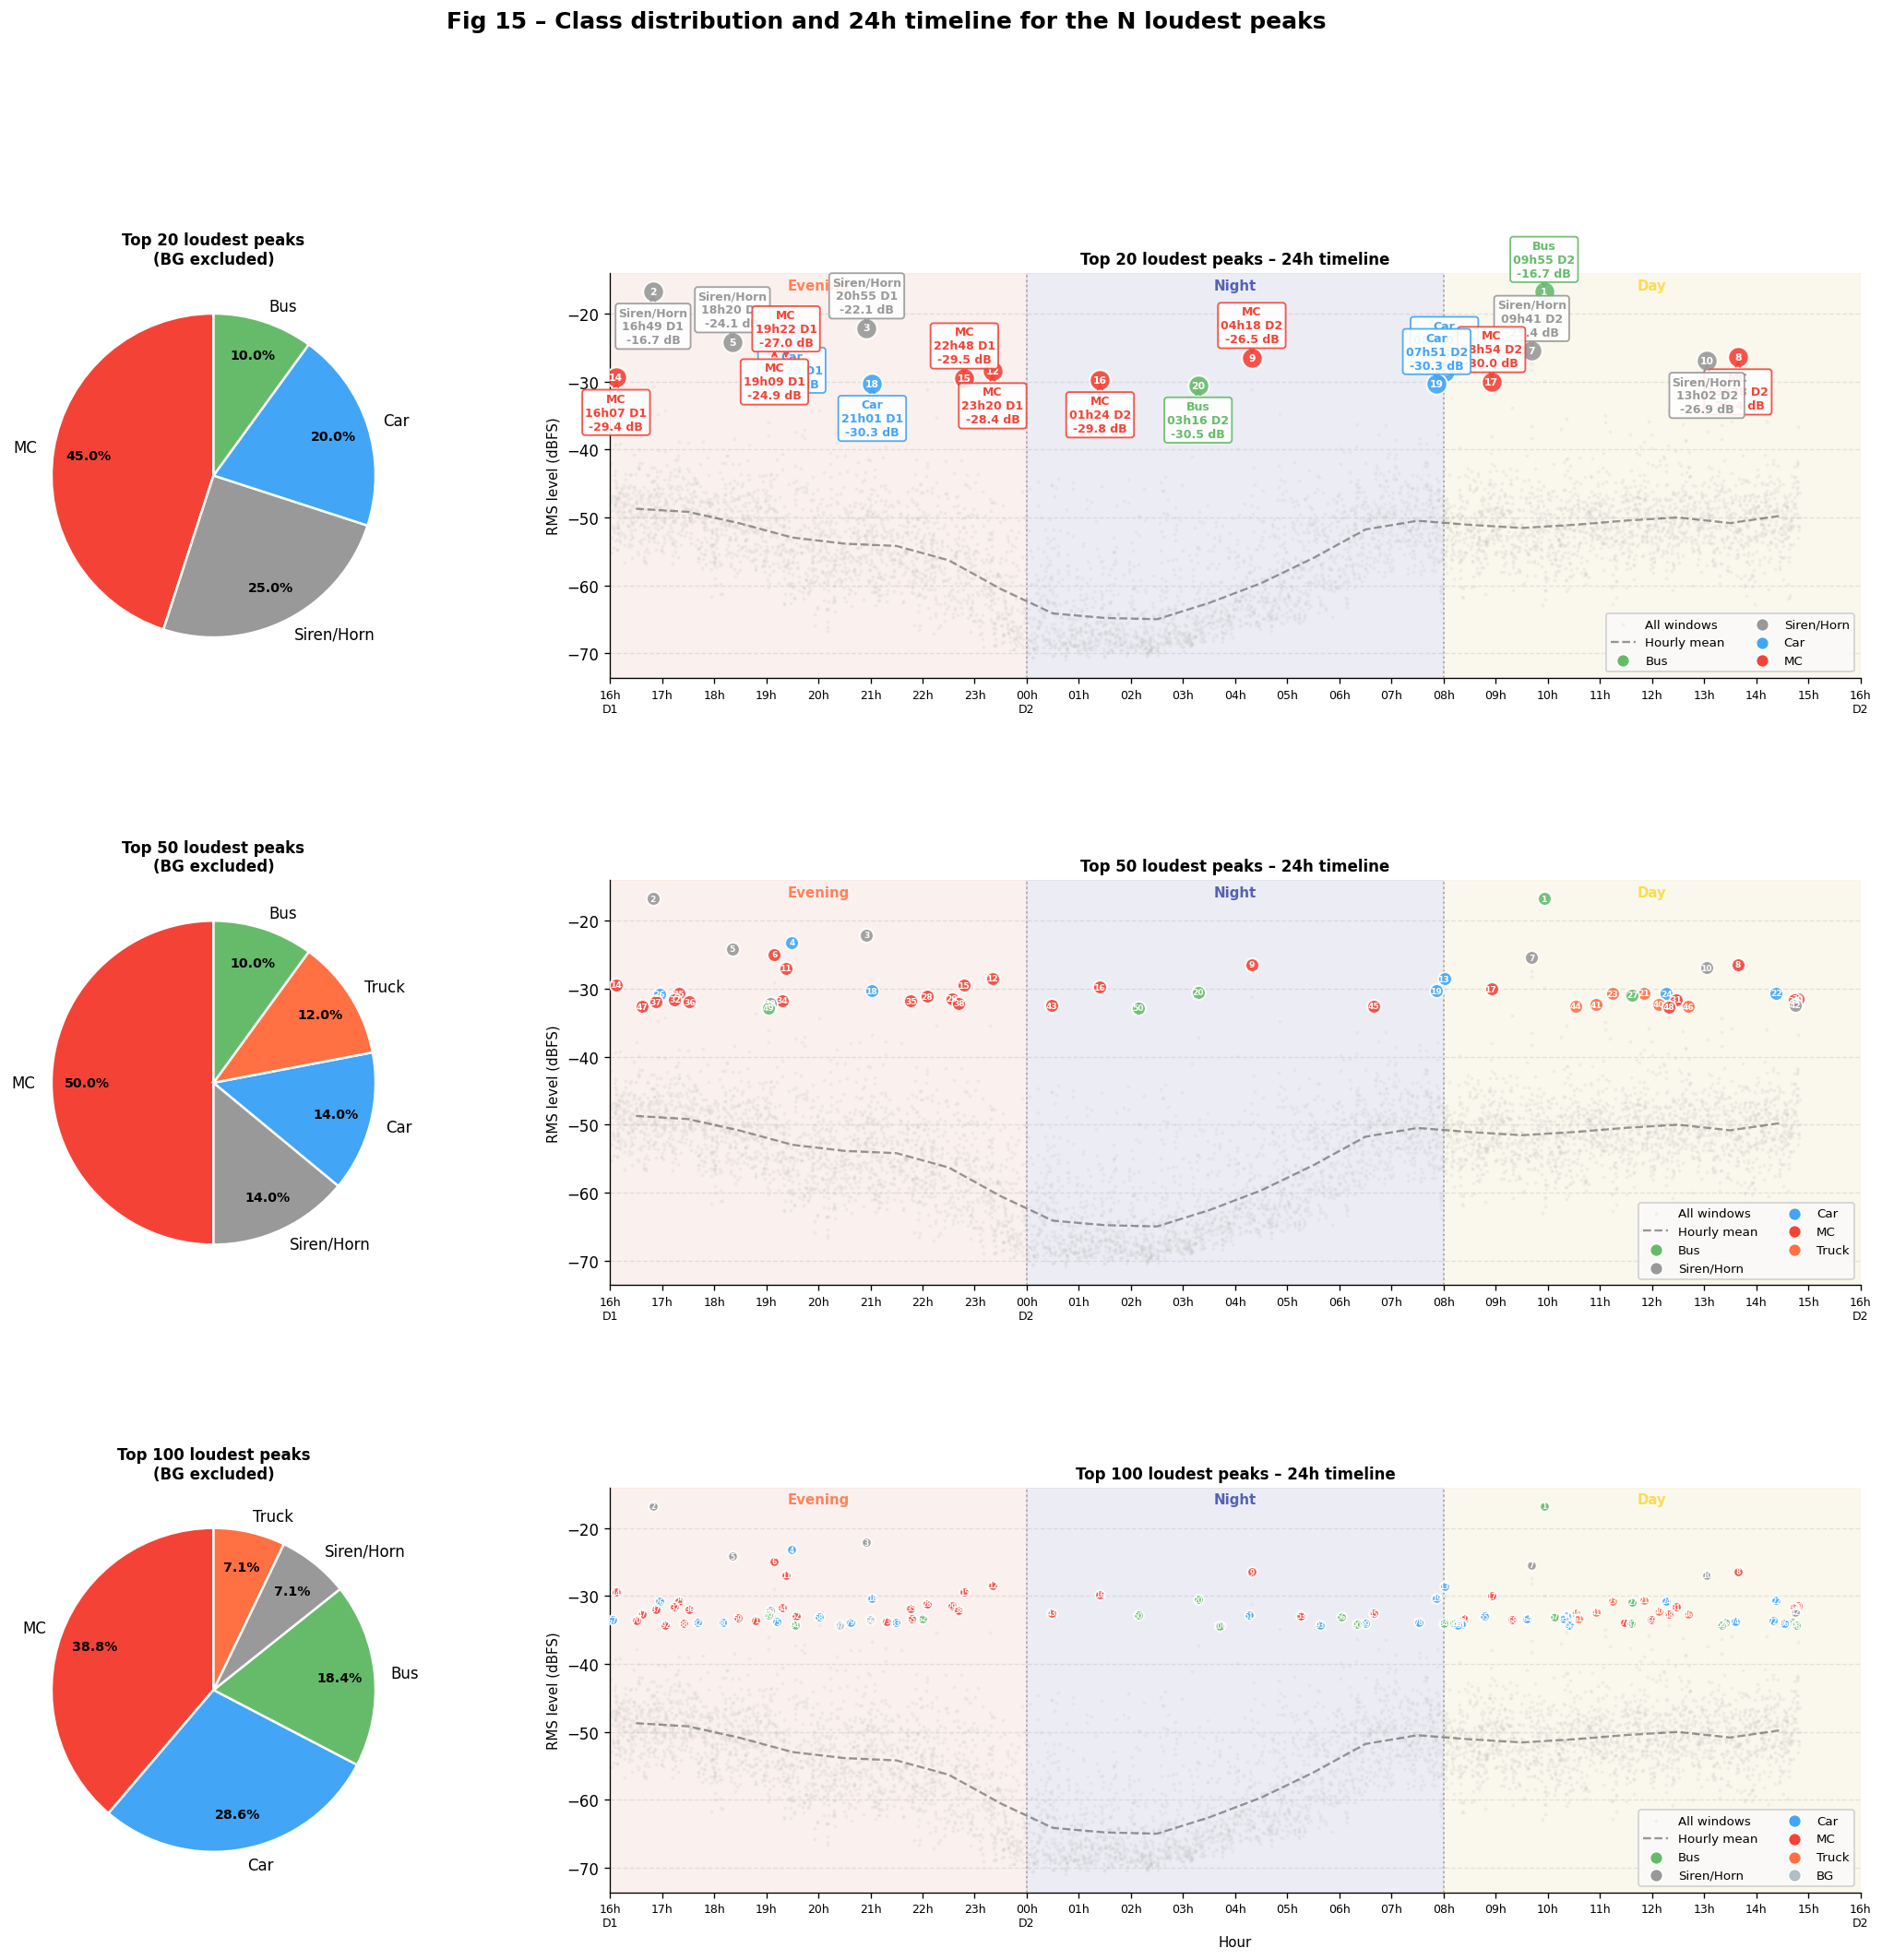

fig15_top_n_peaks.png


In [ ]:
# ── Fig 15 - Class distribution + annotated timeline for top-20 / 50 / 100 peaks ──

# --- Helper: extend deduplication to top-N, reusing already-labelled rows ----------
def get_top_n_peaks(n, base_df=None):
    """De-duplicate df_peaks down to the n loudest, MIN_GAP_S apart.
    Reuses class_at_peak from base_df where available to avoid redundant calls."""
    df_sorted = df_peaks.sort_values('db_peak', ascending=False).reset_index(drop=True)
    selected, kept_times = [], []
    for _, row in df_sorted.iterrows():
        t_abs = (row['abs_hour'] - 16) * 3600 + row['t_peak']
        if any(abs(t_abs - t2) < MIN_GAP_S for t2 in kept_times):
            continue
        selected.append(row)
        kept_times.append(t_abs)
        if len(selected) == n:
            break
    df_n = pd.DataFrame(selected).reset_index(drop=True)
    # Reuse labels already computed in base_df
    if base_df is not None and 'class_at_peak' in base_df.columns:
        known = base_df.set_index(['filename', 't_peak'])['class_at_peak'].to_dict()
        df_n['class_at_peak'] = df_n.apply(
            lambda r: known.get((r['filename'], r['t_peak']),
                                class_at_time(r['filename'], r['t_peak'])), axis=1)
    else:
        df_n['class_at_peak'] = df_n.apply(
            lambda r: class_at_time(r['filename'], r['t_peak']), axis=1)
    return df_n

print("Building top-50 and top-100 peak lists (reuses top-20 labels)...")
peaks_50  = get_top_n_peaks(50,  base_df=df_peaks_dedup)
peaks_100 = get_top_n_peaks(100, base_df=peaks_50)
print("Done.")

# --- Pre-compute hourly mean once -----------------------------------------------
_hourly_mean_fig15 = (
    df_peaks
    .assign(hour_bin=df_peaks['abs_hour'].apply(lambda h: int(h)))
    .groupby('hour_bin')['db_peak'].mean()
    .reindex(range(16, 40))
)
_sample_fig15 = df_peaks.sample(min(6000, len(df_peaks)), random_state=42)

TOP_N_LIST = [
    (20,  df_peaks_dedup, 'Top 20 loudest peaks'),
    (50,  peaks_50,       'Top 50 loudest peaks'),
    (100, peaks_100,      'Top 100 loudest peaks'),
]

fig = plt.figure(figsize=(22, 19))
fig.suptitle('Fig 15 – Class distribution and 24h timeline for the N loudest peaks',
             fontsize=15, fontweight='bold', y=1.005)

gs = gridspec.GridSpec(3, 2, figure=fig,
                       width_ratios=[1, 2.6],
                       hspace=0.50, wspace=0.18)

for row_idx, (n, df_n, subtitle) in enumerate(TOP_N_LIST):

    # ── Left: pie chart ──────────────────────────────────────────────────────
    ax_pie = fig.add_subplot(gs[row_idx, 0])

    cls_counts = df_n['class_at_peak'].value_counts()
    non_bg = cls_counts.drop(['BG', 'Tram'], errors='ignore')
    if non_bg.empty:
        non_bg = cls_counts

    pie_colors = [CLASS_COLORS.get(normalize_class(c), '#999') for c in non_bg.index]
    wedges, texts, autotexts = ax_pie.pie(
        non_bg.values, labels=non_bg.index, colors=pie_colors,
        autopct='%1.1f%%', startangle=90, pctdistance=0.78,
        wedgeprops=dict(linewidth=1.5, edgecolor='white'))
    for t in autotexts:
        t.set_fontsize(8.5); t.set_fontweight('bold')
    ax_pie.set_title(f'{subtitle}', fontsize=10, fontweight='bold')

    # ── Right: 24h timeline ──────────────────────────────────────────────────
    ax_tl = fig.add_subplot(gs[row_idx, 1])

    # Period shading and boundaries
    for pname, ps, pe in period_ranges:
        ax_tl.axvspan(ps, pe, color=PERIOD_COLORS[pname], alpha=0.07, zorder=0)
    for xv in [24, 32]:
        ax_tl.axvline(xv, color='#aaa', linewidth=1.2, linestyle=':', zorder=4)

    # Background scatter (all windows)
    ax_tl.scatter(
        _sample_fig15['abs_hour'] + _sample_fig15['t_peak'] / 3600,
        _sample_fig15['db_peak'],
        c='#cccccc', s=2, alpha=0.15, zorder=1, label='All windows')

    # Hourly mean
    ax_tl.plot(_hourly_mean_fig15.index + 0.5, _hourly_mean_fig15.values,
               color='#555', linewidth=1.4, linestyle='--', alpha=0.6,
               zorder=2, label='Hourly mean')

    # Marker / font sizes scale with N
    if   n == 20:  msize, fsize, do_annot = 180, 6.5, True
    elif n == 50:  msize, fsize, do_annot =  80, 5.5, False
    else:          msize, fsize, do_annot =  40, 4.5, False

    for rank, peak_row in df_n.iterrows():
        x     = peak_row['abs_hour'] + peak_row['t_peak'] / 3600
        y     = peak_row['db_peak']
        cls   = normalize_class(peak_row['class_at_peak'])
        color = CLASS_PEAK_COLORS.get(cls, '#999')

        ax_tl.scatter(x, y, s=msize, color=color, zorder=6,
                      alpha=0.9, edgecolors='white', linewidths=1.2)
        ax_tl.text(x, y, str(rank + 1), ha='center', va='center',
                   fontsize=fsize, fontweight='bold', color='white', zorder=7)

        if do_annot:
            offset_y = 1.8 if rank % 2 == 0 else -2.2
            va_side  = 'bottom' if rank % 2 == 0 else 'top'
            hh  = int(peak_row['abs_hour']) % 24
            mm  = int((peak_row['abs_hour'] % 1) * 60)
            day = 'D2' if peak_row['abs_hour'] >= 24 else 'D1'
            label = CLASS_SHORT.get(cls, cls)
            ax_tl.annotate(
                f"{label}\n{hh:02d}h{mm:02d} {day}\n{y:.1f} dB",
                xy=(x, y), xytext=(x, y + offset_y),
                ha='center', va=va_side, fontsize=7.5,
                fontweight='bold', color=color,
                arrowprops=dict(arrowstyle='->', color=color, lw=1.1),
                bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                          edgecolor=color, alpha=0.90, linewidth=1.1),
                zorder=8)

    # Legend: one entry per unique class in this subset
    seen = set()
    for _, peak_row in df_n.iterrows():
        cls = normalize_class(peak_row['class_at_peak'])
        if cls not in seen:
            color = CLASS_PEAK_COLORS.get(cls, '#999')
            ax_tl.scatter([], [], s=70, color=color,
                          label=CLASS_SHORT.get(cls, cls).replace('\n', '/'),
                          edgecolors='white', linewidths=1)
            seen.add(cls)

    # Period name labels
    ylo, yhi = ax_tl.get_ylim()
    for pname, ps, pe in period_ranges:
        ax_tl.text((ps + pe) / 2, yhi - (yhi - ylo) * 0.04, pname,
                   ha='center', fontsize=9, color=PERIOD_COLORS[pname],
                   fontweight='bold', alpha=0.85)

    ax_tl.set_xticks(xticks)
    ax_tl.set_xticklabels(xlabels, fontsize=7.5)
    ax_tl.set_xlim(16, 40)
    ax_tl.set_ylabel('RMS level (dBFS)', fontsize=9)
    ax_tl.set_title(f'{subtitle} – 24h timeline', fontsize=10, fontweight='bold')
    ax_tl.grid(axis='y', alpha=0.3, linestyle='--')
    ax_tl.legend(loc='lower right', fontsize=8, ncol=2, framealpha=0.9)
    if row_idx == 2:
        ax_tl.set_xlabel('Hour', fontsize=9)

plt.savefig('fig15_top_n_peaks.png', dpi=150, bbox_inches='tight')
plt.show()
print("fig15_top_n_peaks.png")

---
## 10. Summary

In [32]:
print("=" * 65)
print("  24H ANALYSIS SUMMARY")
print("=" * 65)
print(f"  Files processed      : {len(df_files)}")
print(f"  Total events         : {len(df_events)}")
print(f"  Non-BG events        : {len(df_events[df_events['class'] != 'BG'])}")
print()
print("  Sound levels by period:")
for period in ['Evening', 'Night', 'Day']:
    m = df_files[df_files['period'] == period]['db_rms'].mean()
    s = df_files[df_files['period'] == period]['db_rms'].std()
    if not np.isnan(m):
        print(f"    {period:<8}: {m:.1f} dBFS  (std={s:.1f})")
print()
valid   = df_hourly.dropna(subset=['db_mean'])
loud_h  = valid.loc[valid['db_mean'].idxmax()]
quiet_h = valid.loc[valid['db_mean'].idxmin()]
print(f"  Loudest hour  : {abs_hour_label(loud_h['hour_bin'])}  ->  {loud_h['db_mean']:.1f} dBFS")
print(f"  Quietest hour : {abs_hour_label(quiet_h['hour_bin'])}  ->  {quiet_h['db_mean']:.1f} dBFS")
print()
print("  Inference improvements applied:")
print("    - Tram suppressed (redistributed to 2nd model choice)")
print("    - TTA x5 augmentations for MC and Siren")
print("    - Multi-resolution 1s / 5s fusion for Horn and Siren")
print("    - Adaptive thresholds: MC/Siren=0.42, Bus/Truck=0.48, others=0.50")
print()
print("  Output CSV files:")
for fn in ['24h_summary.csv', '24h_events.csv']:
    status = 'OK' if Path(fn).exists() else 'missing'
    print(f"    [{status}] {fn}")
print()
print("  Figures generated:")
figs = [
    'fig1_sound_levels.png',       'fig2_vehicles_dbfs.png',
    'fig3_period_comparison.png',  'fig4_heatmap.png',
    'fig5_class_distribution.png', 'fig6_multi_metric.png',
    'fig7_top20_timeline.png',     'fig8_vehicle_noise.png',
    'fig9_gantt.png',              'fig10_correlation.png',
    'fig11_radar.png',             'fig12_stacked_area.png',
    'fig13_confidence.png',        'fig14_boxplot_activity.png',
]
for fn in figs:
    status = 'OK' if Path(fn).exists() else 'pending'
    print(f"    [{status}] {fn}")
print("=" * 65)

  24H ANALYSIS SUMMARY
  Files processed      : 2738
  Total events         : 12839
  Non-BG events        : 7163

  Sound levels by period:
    Evening : -51.0 dBFS  (std=4.8)
    Night   : -57.0 dBFS  (std=7.1)
    Day     : -49.0 dBFS  (std=2.9)

  Loudest hour  : 16h D1  ->  -47.2 dBFS
  Quietest hour : 02h D2  ->  -62.6 dBFS

  Inference improvements applied:
    - Tram suppressed (redistributed to 2nd model choice)
    - TTA x5 augmentations for MC and Siren
    - Multi-resolution 1s / 5s fusion for Horn and Siren
    - Adaptive thresholds: MC/Siren=0.42, Bus/Truck=0.48, others=0.50

  Output CSV files:
    [OK] 24h_summary.csv
    [OK] 24h_events.csv

  Figures generated:
    [OK] fig1_sound_levels.png
    [OK] fig2_vehicles_dbfs.png
    [OK] fig3_period_comparison.png
    [OK] fig4_heatmap.png
    [OK] fig5_class_distribution.png
    [OK] fig6_multi_metric.png
    [OK] fig7_top20_timeline.png
    [OK] fig8_vehicle_noise.png
    [OK] fig9_gantt.png
    [OK] fig10_correlation.png

Time of execution of the file :

In [33]:
# ─── Total notebook runtime ──────────────────────────────────
_elapsed = _time.perf_counter() - _NOTEBOOK_START
_h, _rem = divmod(int(_elapsed), 3600)
_m, _s   = divmod(_rem, 60)

print("=" * 60)
print("TOTAL NOTEBOOK RUNTIME")
print("=" * 60)
if _h:
    print(f"  {_h}h {_m:02d}min {_s:02d}s  ({_elapsed:.1f}s total)")
elif _m:
    print(f"  {_m}min {_s:02d}s  ({_elapsed:.1f}s total)")
else:
    print(f"  {_s}s  ({_elapsed:.2f}s total)")
print("=" * 60)

TOTAL NOTEBOOK RUNTIME
  5h 15min 10s  (18910.0s total)
